# Bedrock Runtime vs Mantle Standard vs Mantle Reserved (RU4) — Performance

mantle_oss_perf_ru4.ipynb. ru4 is a methodology rework of ru3: three new code cells, ten rewritten cells, and twenty cells left byte-identical.
Unchanged cells. Title, Steps 1 through 3c, Step 4a, teardown, Step 7, the archived-projects appendix, the report intro, and Logs 1/3 are identical.

### New cells in ru4

  - Measurement harness after the config cell. Adds a shared streaming benchmark with per-delta timestamps, percentile stats, quiet-gap helper, CloudWatch minute-bucket bookkeeping, and a concurrency ramp function.
    Replaces per-cell timing code that reported mean plus standard deviation and a generation-rate metric that divided by near zero.
  - Negative control after teardown. Sends the project header with no reservation in existence to complete a 2x2 routing test.
  - Logs 2b/3 attribution. Attributes CloudWatch minutes to arms via the quiet gaps and produces the routing verdict, which may now conclude "no signal".

### Rewritten cells

  - Config cell. New RU_MAX_QUANTITY ceiling, new scale_reservation and autoscale_reservation helpers, project name changed to mantle-ru-perf-082701, and an explicit 120-second SDK timeout. A long comment documents
    that a custom http_client timeout was silently ignored, which caused the apparent hang.
  - Step 4b client. Sets timeout and max_retries=0 on the SDK client directly.
  - Tier comparison markdown. Rewritten to describe the interleaved latency cell, the temporally isolated routing cell, the negative control, and the A/A control.
  - Tier comparison 1/4. Arms now interleave per round with rotating order, per-prompt nonces, a discarded warm-up per arm, and an on-demand A/B pair as a noise-floor control. Runs went from 10 to 12. Registers its window as mixed for attribution.
  - Tier comparison 2/4. Was a 20-request burst reading response headers. Now a concurrency ramp auto-sized to exceed reserved capacity, with quiet gaps between arms and optional autoscale up to the RU ceiling.
  - Tier comparison 4/4. Reports p50/p90/p95/p99, inter-token latency, ms per output token, and the tier effect measured against the A/A gap. The tok/s panel was removed.
  - On-demand TPM ceiling. Local request and ramp loop replaced by the shared harness. Step rows now carry TTFT, end-to-end, and inter-token percentiles.
  - Step 6 scaling. Routed through scale_reservation so the ceiling clamps. Default target changed from 2 to 4 RU.
  - Logs 2/3. Now fetch-only. The routing verdict text was replaced with a warning that window totals are not attribution.
  - Logs 3/3 report. Derives the reservation's active window from the invocation log, tags each inference call as inside or outside it, drops the old verdict, and adds new sections for routing evidence, latency tables, the negative control, and the TPM ceiling.


---

## Reservations / Reservation Units (RU) — Bedrock Mantle Private Preview

Everything above exercises the **standard (on-demand) tier** and is unchanged. The sections
below add **reserved-tier** access on top of it.

A **Reservation Unit (RU)** is a model-specific throughput allotment measured in *blended*
tokens per minute: `blended_tpm = input_tpm + burndown_rate * output_tpm`. Reservations are
scoped to a **project + region + model** triple. Inference is routed to reserved capacity
simply by sending the `openai-project` header — no application routing logic. Traffic beyond
the reserved quota **spills over** to the standard tier and is flagged in a response header.

| Step | Call |
|---|---|
| 1 | `POST /v1/organization/projects` — create the project |
| 2 | (local) size the reservation — compute RUs needed |
| 3 | `POST /bedrock/v1/reservations` — create, then poll until `active` |
| 4 | `POST /v1/chat/completions` with `openai-project` — reserved-tier inference |
| 6 | `PUT /bedrock/v1/reservations/{id}` — scale RUs up/down |
| 7 | `DELETE /bedrock/v1/reservations/{id}` — cancel (billing continues until you do) |

**Assumptions** (`ru_assumptions.txt`)
1. RUs are allocated from **us-east-1**.
2. The existing Mantle bearer token (`BEDROCK_MANTLE_TOKEN`) is sufficient for RU access.
3. Multiple RUs may be created for a single project — start with **2**.

> **Billing:** a reservation bills from the moment it goes active (gpt-oss-120b:
> **$5.77/RU-hour**, first hour billed in full, per-minute prorating after that).
> Every mutating cell below is a **no-op until `CONFIRM_SPEND = True`**. Run the cancel
> cell when you are done.


In [1]:
# --- RU configuration + raw-HTTP helpers -----------------------------------
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor

import httpx
import requests

RU_REGION     = "us-east-1"          # assumption 1
RU_MODEL      = "openai.gpt-oss-120b"
RU_QUANTITY   = 2                    # DEFAULT reservation size (assumption 3)
RU_MAX_QUANTITY = 4                  # auto-scale ceiling. Every RU-count change goes
                                     # through scale_reservation(), which clamps to
                                     # this, so nothing can exceed 4 RU.
RU_PROJECT_NAME = "mantle-ru-perf-082701"

CONFIRM_SPEND = True #False   # <-- flip to True to allow create / adjust / cancel

MANTLE_ENDPOINT = f"https://bedrock-mantle.{RU_REGION}.api.aws"
RU_TOKEN = os.environ["BEDROCK_MANTLE_TOKEN"]   # assumption 2

# Mantle's OpenAI-compatible surface is model-dependent: google.gemma-4-* live
# under /openai/v1, everything else (incl. gpt-oss) under /v1.
RU_BASE_PATH = "/openai/v1" if RU_MODEL.startswith("google.gemma-4") else "/v1"

# Per-request timeout for every OpenAI SDK client below, passed explicitly as
# OpenAI(timeout=...). Why explicitly: given only a custom http_client, the SDK
# INHERITS that client's timeout -- and logging_http_client() sets 600s -- so every
# benchmark client silently ran with a 600s read timeout plus the SDK default
# max_retries=2. That is what made the tier-comparison cell look hung: it fires its
# warm-up calls before printing anything, so one unresponsive stream shows [*] and
# no output for up to 10 minutes, and 75 slow calls stretch into hours.
#
# Measured, openai 2.52.0:
#   OpenAI(http_client=httpx.Client(timeout=600)) -> Timeout(600)   <- what we had
#   OpenAI(http_client=httpx.Client(timeout=6.0)) -> Timeout(6.0)
#   OpenAI(http_client=httpx.Client(timeout=5.0)) -> Timeout(read=600)
#       ^ 5.0 is httpx's OWN default, so the SDK treats it as unset and substitutes
#         its own 600s -- relying on the http_client is doubly unreliable.
#   OpenAI(timeout=120, http_client=...)          -> 120           <- the fix
# A read timeout that fires mid-stream is not retried, so max_retries multiplies
# connect/request failures only, not stalls.
SDK_TIMEOUT_S = 120

# Filled in by the cells below.
PROJECT_ID     = os.environ.get("MANTLE_PROJECT_ID") or None
RESERVATION_ID = None

RESERVATION_HEADERS = (
    "x-amzn-usage-reservation-quota",            # blended TPM granted
    "x-amzn-usage-reservation-remaining-quota",   # blended TPM left this window
    "x-amzn-usage-reservation-spillover",         # "standard" => served on-demand
)

# --- Mantle API invocation log ----------------------------------------------
# Every Mantle API call this kernel makes lands in INVOCATION_LOG — raw
# mantle_request() calls below, and OpenAI-SDK calls via logging_http_client()
# (an httpx response hook). The "Invocation logs + CloudWatch logs" cells at the
# bottom of the notebook render it and save it into a markdown report.
INVOCATION_LOG = []

_REQUEST_ID_HEADERS = ("x-request-id", "x-amzn-requestid", "apigw-requestid")


def _handled_by(path, project_sent, res_hdrs):
    """Best-effort on-demand-pool vs reservation-unit attribution for one call.

    Only response headers are visible client-side, and the preview does not
    always return them on reserved-tier calls (observed in Step 4) — those rows
    read 'indeterminate'; the CloudWatch cells' BurnDownConsumed /
    SpillOverTokenCount metrics are the authoritative routing signal.
    """
    if not (path.endswith("/chat/completions") or path.endswith("/responses")):
        return ""                     # control plane — not routed to either pool
    if res_hdrs.get("x-amzn-usage-reservation-spillover") == "standard":
        return "on-demand (spillover)"
    if res_hdrs:
        return "reservation (RU)"
    return "indeterminate (no res headers)" if project_sent else "on-demand"


def _record_invocation(*, source, method, path, status, headers, project_sent,
                       latency_ms=None, usage=None, model=None):
    lower = {k.lower(): v for k, v in (headers or {}).items()}
    res_hdrs = {n: lower[n] for n in RESERVATION_HEADERS if n in lower}
    usage = usage if isinstance(usage, dict) else {}
    INVOCATION_LOG.append({
        "ts_utc": time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()),
        "epoch": time.time(),
        "source": source,             # raw = requests, sdk = OpenAI client
        "method": method,
        "path": path,
        "status": status,
        "request_id": next((lower[h] for h in _REQUEST_ID_HEADERS if h in lower), ""),
        "project": project_sent or "",
        "model": model or "",
        # chat/completions usage says prompt_/completion_tokens, Responses API
        # says input_/output_tokens — accept either.
        "in_tokens": usage.get("prompt_tokens", usage.get("input_tokens")),
        "out_tokens": usage.get("completion_tokens", usage.get("output_tokens")),
        "quota": res_hdrs.get("x-amzn-usage-reservation-quota"),
        "remaining_quota": res_hdrs.get("x-amzn-usage-reservation-remaining-quota"),
        "spillover": res_hdrs.get("x-amzn-usage-reservation-spillover"),
        "handled_by": _handled_by(path, project_sent, res_hdrs),
        "latency_ms": round(latency_ms, 1) if latency_ms is not None else None,
    })


_HTTPX_T0 = {}                        # id(request) -> perf_counter at send time


def _httpx_on_request(request):
    _HTTPX_T0[id(request)] = time.perf_counter()


def _httpx_on_response(response):
    """httpx response hook — fires when headers arrive; the body may still be
    streaming, so it must not be touched here. Consequences: no token usage for
    SDK calls, and latency_ms is time-to-headers, not end-to-end (the benchmark
    cells measure real TTFT/latency themselves)."""
    req = response.request
    t0 = _HTTPX_T0.pop(id(req), None)
    try:
        req_model = json.loads(req.content or b"{}").get("model")
    except Exception:
        req_model = None
    _record_invocation(
        source="sdk", method=req.method, path=req.url.path,
        status=response.status_code, headers=dict(response.headers),
        project_sent=req.headers.get("openai-project"),
        latency_ms=(time.perf_counter() - t0) * 1000 if t0 is not None else None,
        model=req_model,
    )


def logging_http_client(timeout=600):
    """httpx client for OpenAI(...) that records every call into INVOCATION_LOG."""
    return httpx.Client(timeout=timeout, event_hooks={
        "request": [_httpx_on_request], "response": [_httpx_on_response]})


def mantle_request(method, path, *, project=None, body=None, region=None, timeout=120):
    """Raw Mantle call. Returns (status_code, headers, parsed_body).

    region overrides RU_REGION for that one call (used by the discovery cell to
    sweep for reservations left running in other regions). Every call is also
    appended to INVOCATION_LOG.
    """
    endpoint = f"https://bedrock-mantle.{region}.api.aws" if region else MANTLE_ENDPOINT
    headers = {"Authorization": f"Bearer {RU_TOKEN}", "Content-Type": "application/json"}
    if project:
        headers["openai-project"] = project
    t0 = time.perf_counter()
    resp = requests.request(
        method, f"{endpoint}{path}", headers=headers, json=body, timeout=timeout
    )
    try:
        parsed = resp.json()
    except ValueError:
        parsed = resp.text
    _record_invocation(
        source="raw", method=method.upper(), path=path, status=resp.status_code,
        headers=dict(resp.headers), project_sent=project,
        latency_ms=(time.perf_counter() - t0) * 1000,
        usage=parsed.get("usage") if isinstance(parsed, dict) else None,
        model=body.get("model") if isinstance(body, dict) else None,
    )
    return resp.status_code, dict(resp.headers), parsed


def reservation_headers(headers):
    """Pull the x-amzn-usage-reservation-* headers out of a response (case-insensitive)."""
    lower = {k.lower(): v for k, v in headers.items()}
    return {name: lower[name] for name in RESERVATION_HEADERS if name in lower}


def res_project_id(res):
    """Bare proj_... id of the project that OWNS this reservation, or None.

    Two traps this exists to close:
      1. The API reports project_id as a full ARN
         (arn:aws:bedrock-mantle:<region>:<acct>:project/proj_xxx), but the
         openai-project header needs the bare id — so always strip it.
      2. Never take the project from an enclosing loop over list_projects():
         GET /bedrock/v1/reservations IGNORES openai-project and returns every
         reservation in the region, so that pairing is arbitrary. GET/DELETE on
         a single reservation DO enforce the header, so a mismatched pair 404s.
    """
    return (res.get("project_id") or "").rstrip("/").split("/")[-1] or None


def show(status, headers, body, *, max_chars=2000):
    print("HTTP", status)
    for k, v in reservation_headers(headers).items():
        print(f"  {k}: {v}")
    text = json.dumps(body, indent=2) if isinstance(body, (dict, list)) else str(body)
    print(text[:max_chars])


def cancel_reservation(reservation_id, *, project=None, region=None, verify=True):
    """Cancel a reservation so it stops billing. Returns True on success.

    Deliberately NOT gated by CONFIRM_SPEND: cancelling only ever saves money,
    and a kernel restart resets CONFIRM_SPEND to False — that must never leave
    you unable to tear down a reservation that is actively billing.
    """
    if not reservation_id:
        print("cancel_reservation: no reservation id given.")
        return False
    path = f"/bedrock/v1/reservations/{reservation_id}"
    status, headers, body = mantle_request(
        "DELETE", path, project=project or PROJECT_ID, region=region
    )
    print(f"DELETE {path} [{region or RU_REGION}] -> HTTP {status}")
    if status >= 300:
        show(status, headers, body, max_chars=400)
        return False
    if verify:
        vstatus, _, check = mantle_request(
            "GET", path, project=project or PROJECT_ID, region=region
        )
        res = check.get("reservation", check) if isinstance(check, dict) else {}
        print(f"  status now = {res.get('status') or f'HTTP {vstatus}'}"
              f"  (first hour billed in full; billing stops now)")
    return True


def scale_reservation(quantity, *, project=None, region=None):
    """Resize the reservation, clamped to [1, RU_MAX_QUANTITY]. Returns the new size.

    Every path that changes the RU count goes through here, so the ceiling cannot
    be bypassed by editing a cell-local variable. Reads RU_CATALOG (Step 2 cell) at
    call time.
    """
    global RU_QUANTITY
    if not RESERVATION_ID:
        print("scale_reservation: no RESERVATION_ID in this kernel.")
        return RU_QUANTITY
    want = max(1, min(int(quantity), RU_MAX_QUANTITY))
    if want != int(quantity):
        print(f"scale_reservation: {quantity} clamped to {want} "
              f"(RU_MAX_QUANTITY={RU_MAX_QUANTITY}).")
    if want == RU_QUANTITY:
        print(f"scale_reservation: already at {want} RU.")
        return RU_QUANTITY
    if not require_spend(f"PUT /bedrock/v1/reservations/{RESERVATION_ID}"
                         f"  {RU_QUANTITY} -> {want} RU"):
        return RU_QUANTITY
    status, headers, body = mantle_request(
        "PUT", f"/bedrock/v1/reservations/{RESERVATION_ID}",
        project=project or PROJECT_ID, region=region,
        body={"reservation_units": {"unit": "model_units", "quantity": want}})
    if status >= 300:
        show(status, headers, body, max_chars=400)
        return RU_QUANTITY
    RU_QUANTITY = want
    spec = RU_CATALOG[RU_MODEL]
    print(f"reservation now {RU_QUANTITY} RU "
          f"({RU_QUANTITY * spec['tpm_per_ru']:,} blended TPM, "
          f"${RU_QUANTITY * spec['usd_per_ru_hour']:.2f}/hour)")
    return RU_QUANTITY


def autoscale_reservation(step_rows, *, headroom=0.90):
    """Step the reservation UP when a ramp saturated it, capped at RU_MAX_QUANTITY.

    Returns (new_quantity, reason). Never scales down -- shrinking mid-measurement
    would invalidate the ramp that was just recorded. Saturation is any 429, any
    spillover header, or a step whose blended TPM reached `headroom` of the current
    capacity.
    """
    spec = RU_CATALOG[RU_MODEL]
    cap = RU_QUANTITY * spec["tpm_per_ru"]
    peak = max((s.get("blended_tpm") or 0.0 for s in step_rows), default=0.0)
    n429 = sum(s.get("throttled_429") or 0 for s in step_rows)
    spill = sum(s.get("spillover_hits") or 0 for s in step_rows)
    if RU_QUANTITY >= RU_MAX_QUANTITY:
        return RU_QUANTITY, (f"already at the {RU_MAX_QUANTITY} RU ceiling; peak "
                             f"{peak:,.0f} of {cap:,} blended TPM")
    if not (n429 or spill or peak >= headroom * cap):
        return RU_QUANTITY, (f"no saturation: peak {peak:,.0f} blended TPM = "
                             f"{peak / cap:.0%} of {cap:,}, 429s={n429}, "
                             f"spillover={spill}")
    why = (f"429s={n429}, spillover={spill}, peak {peak:,.0f} blended TPM = "
           f"{peak / cap:.0%} of {cap:,}")
    print(f"autoscale: saturation detected ({why})")
    return scale_reservation(min(RU_QUANTITY * 2, RU_MAX_QUANTITY)), why


def require_spend(action):
    """Gate every billable / mutating call behind an explicit opt-in."""
    if not CONFIRM_SPEND:
        print(f"[skipped] {action}\n          set CONFIRM_SPEND = True to execute.")
        return False
    return True


print(f"endpoint : {MANTLE_ENDPOINT}")
print(f"model    : {RU_MODEL}  (inference path {RU_BASE_PATH})")
print(f"RUs      : {RU_QUANTITY} (auto-scale ceiling {RU_MAX_QUANTITY})")
print(f"spend    : {'ENABLED' if CONFIRM_SPEND else 'blocked (CONFIRM_SPEND=False)'}")
print(f"invlog   : ON — every Mantle API call is recorded in INVOCATION_LOG "
      f"(report cells at the bottom)")

endpoint : https://bedrock-mantle.us-east-1.api.aws
model    : openai.gpt-oss-120b  (inference path /v1)
RUs      : 2 (auto-scale ceiling 4)
spend    : ENABLED
invlog   : ON — every Mantle API call is recorded in INVOCATION_LOG (report cells at the bottom)


/home/alfred/anaconda3/envs/vllm/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# --- Measurement harness: instrumented streaming, percentiles, arm bookkeeping ---
# Shared by the tier latency profile, the routing-evidence probe and the TPM
# ceiling sweep, so all three measure latency the same way and their numbers are
# comparable.
#
# Why this replaced the per-cell timing code: the previous harness kept two
# timestamps per request (first output-text delta, end of stream) and reported
# mean +/- sd. That cannot express a tail or inter-token jitter, and its
# out_tokens / (latency - ttft) "generation rate" divides by ~0 whenever the whole
# answer arrives in a single delta -- it reported 18,000 tok/s on short prompts,
# which is an artefact of the metric, not a throughput. Everything below is
# derived from per-delta arrival timestamps instead.
#
# blended_tokens() and sweep_arm() read RU_CATALOG, which the Step 2 sizing cell
# below defines. That is a forward reference resolved at call time -- fine because
# every call site is downstream of Step 2, but run Step 2 before calling these by
# hand.
import math
import statistics
import time

import openai

# Every measured arm appends one entry here (see record_arm_window). The
# CloudWatch cell attributes per-minute BurnDownConsumed to these windows: that is
# the only tier-attribution channel that depends neither on the
# x-amzn-usage-reservation-* response headers (absent in the preview) nor on the
# Project metric dimension (observed publishing everything under "default").
ARM_WINDOWS = []

_WSR_HEALTHY = True     # with_streaming_response works on this SDK/endpoint pair


def blended_tokens(in_tokens, out_tokens, model):
    """Reservation burn-down currency: input + burndown_rate x output."""
    return in_tokens + RU_CATALOG[model]["burndown_rate"] * out_tokens


def pct_stats(values):
    """n / mean / p50 / p90 / p95 / p99 / min / max for one metric.

    Percentiles rather than mean +/- sd because the thing a reservation is meant
    to buy is the tail, and a mean cannot show one. Callers prefix the keys.
    """
    vals = sorted(v for v in values
                  if v is not None and not (isinstance(v, float) and math.isnan(v)))
    if not vals:
        return {"n": 0}

    def q(p):
        return vals[min(len(vals) - 1, int(round(p * (len(vals) - 1))))]

    return {"n": len(vals), "mean": statistics.fmean(vals),
            "p50": q(0.50), "p90": q(0.90), "p95": q(0.95), "p99": q(0.99),
            "min": vals[0], "max": vals[-1]}


def quiet_gap(seconds, label=""):
    """Idle pause so the arms on either side own their own CloudWatch buckets.

    AWS/BedrockMantle publishes at 60s. Two arms that share a bucket cannot be
    told apart from the metric side -- which is exactly why the earlier run could
    not say whether the reserved arm burned anything. 75s guarantees at least one
    wholly-idle bucket between arms.
    """
    if seconds <= 0:
        return
    print(f"  quiet gap {seconds}s{' - ' + label if label else ''} "
          f"(isolates CloudWatch minute buckets)", flush=True)
    time.sleep(seconds)


def minute_buckets(epoch_start, epoch_end):
    """UTC 'YYYY-mm-dd HH:MM' buckets an interval touches, at CloudWatch's period."""
    stamps = list(range(int(epoch_start), int(epoch_end), 30)) + [epoch_end]
    return sorted({time.strftime("%Y-%m-%d %H:%M", time.gmtime(t)) for t in stamps})


def record_arm_window(arm, *, tier_intent, project_sent, epoch_start, epoch_end,
                      records, model, reservation_id=None, notes=""):
    """Register one measured arm so the CloudWatch cell can attribute to it.

    tier_intent is what the arm was ADDRESSED to ("reserved" / "on-demand"), never
    a claim about where it was served -- that is the open question. Use "mixed"
    for arms that deliberately share minute buckets with another arm (the
    interleaved latency cell); the verdict then excludes those minutes rather than
    mis-attributing them.
    """
    ok = [r for r in records if r.get("status") == "ok"]
    in_tok = sum(r.get("in_tokens") or 0 for r in ok)
    out_tok = sum(r.get("out_tokens") or 0 for r in ok)
    entry = {
        "arm": arm,
        "tier_intent": tier_intent,
        "project_sent": project_sent or "",
        "reservation_id": reservation_id or "",
        "t_start_utc": time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(epoch_start)),
        "t_end_utc": time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime(epoch_end)),
        "epoch_start": epoch_start, "epoch_end": epoch_end,
        "requests": len(records), "ok": len(ok),
        "in_tokens": in_tok, "out_tokens": out_tok,
        "blended_tokens": blended_tokens(in_tok, out_tok, model),
        "minutes": minute_buckets(epoch_start, epoch_end),
        # channel 1: how often the preview actually returned reservation headers
        "res_hdr_hits": sum(1 for r in records if r.get("res_hdrs")),
        "spillover_hits": sum(
            1 for r in records
            if (r.get("res_hdrs") or {}).get("x-amzn-usage-reservation-spillover")
            == "standard"),
        "notes": notes,
    }
    ARM_WINDOWS.append(entry)
    return entry


def _open_stream(client, kwargs):
    """Return (headers, event_iterator, close_fn) for a streamed Responses call.

    with_streaming_response keeps the response headers -- the per-request routing
    evidence that the plain SDK call discards. If the wrapper is unavailable on
    this SDK/endpoint pair the benchmark degrades to header-less streaming (the
    old behaviour) rather than failing the run; the fallback is announced once.
    """
    global _WSR_HEALTHY
    if _WSR_HEALTHY:
        try:
            ctx = client.responses.with_streaming_response.create(**kwargs)
            raw = ctx.__enter__()
            return (dict(raw.headers), raw.parse(),
                    lambda: ctx.__exit__(None, None, None))
        except (AttributeError, TypeError) as e:
            _WSR_HEALTHY = False
            print(f"  [with_streaming_response unavailable ({type(e).__name__}: {e}) "
                  f"- falling back to header-less streaming]")
    return {}, client.responses.create(**kwargs), lambda: None


def stream_bench(client, model, prompt, max_tokens, *, project=None, nonce=None):
    """One streamed Responses-API call, fully instrumented. Never raises.

    Timings, all ms:
      ttft_any_ms   first event of ANY type. For a reasoning model like gpt-oss
                    the reasoning phase sits between this and the first text
                    delta, so reporting only one of the two is misleading.
      ttft_text_ms  first response.output_text.delta -- what the old harness
                    called "TTFT", with the reasoning phase folded into it.
      reasoning_ms  ttft_text_ms - ttft_any_ms, the part that is not queueing.
      e2e_ms        request sent -> stream closed.
      itl_*_ms      gaps between consecutive text deltas (inter-token latency).
                    None when the answer arrived in fewer than 3 deltas, which on
                    this endpoint is the norm for short outputs -- a real property
                    of the transport, not a measurement failure.
      tpot_ms       (e2e - ttft_text) / max(out_tokens - 1, 1).
      ms_per_out_token  e2e / out_tokens -- use this to compare arms whose output
                    lengths differ, so token-count drift is not read as latency.

    project only labels handled_by; the header itself comes from the client's
    default_headers. res_hdrs holds whatever x-amzn-usage-reservation-* headers
    came back, so every latency sample carries its own tier attribution.
    """
    text = f"[req {nonce}] {prompt}" if nonce else prompt
    kwargs = dict(model=model, input=[{"role": "user", "content": text}],
                  max_output_tokens=max_tokens, stream=True)

    deltas, res_hdrs = [], {}
    t_first_any = t_first_text = None
    in_tokens = out_tokens = reasoning_tokens = cached_tokens = 0
    t0 = time.perf_counter()
    try:
        headers, events, close = _open_stream(client, kwargs)
        res_hdrs = reservation_headers(headers)
        try:
            for event in events:
                now = time.perf_counter()
                if t_first_any is None:
                    t_first_any = now - t0
                et = getattr(event, "type", "")
                if et == "response.output_text.delta" and getattr(event, "delta", None):
                    if t_first_text is None:
                        t_first_text = now - t0
                    deltas.append(now - t0)
                elif et == "response.completed":
                    usage = getattr(getattr(event, "response", None), "usage", None)
                    if usage:
                        in_tokens = getattr(usage, "input_tokens", 0) or 0
                        out_tokens = getattr(usage, "output_tokens", 0) or 0
                        _od = getattr(usage, "output_tokens_details", None)
                        reasoning_tokens = getattr(_od, "reasoning_tokens", 0) or 0
                        _id = getattr(usage, "input_tokens_details", None)
                        cached_tokens = getattr(_id, "cached_tokens", 0) or 0
        finally:
            close()
        status = "ok"
    except openai.RateLimitError:
        status = "throttled"
    except openai.APIStatusError as e:
        status = f"error:{e.status_code}"
    except Exception as e:
        status = f"error:{type(e).__name__}"

    e2e = time.perf_counter() - t0
    itls = [(b - a) * 1000 for a, b in zip(deltas, deltas[1:])]
    gen_ms = (e2e - t_first_text) * 1000 if t_first_text is not None else None
    itl = pct_stats(itls) if len(itls) >= 2 else {"n": len(itls)}
    return {
        "status": status,
        "ttft_any_ms": t_first_any * 1000 if t_first_any is not None else None,
        "ttft_text_ms": t_first_text * 1000 if t_first_text is not None else None,
        "reasoning_ms": ((t_first_text - t_first_any) * 1000
                         if None not in (t_first_any, t_first_text) else None),
        "e2e_ms": e2e * 1000,
        "gen_ms": gen_ms,
        "n_deltas": len(deltas),
        "itl_p50_ms": itl.get("p50"), "itl_p90_ms": itl.get("p90"),
        "itl_p99_ms": itl.get("p99"), "itl_max_ms": itl.get("max"),
        "itls_ms": itls,                      # raw, for percentiles pooled across runs
        "tpot_ms": (gen_ms / max(out_tokens - 1, 1)
                    if gen_ms is not None and out_tokens else None),
        "ms_per_out_token": e2e * 1000 / out_tokens if out_tokens else None,
        "in_tokens": in_tokens, "out_tokens": out_tokens,
        "reasoning_tokens": reasoning_tokens, "cached_tokens": cached_tokens,
        "res_hdrs": res_hdrs,
        "handled_by": _handled_by("/v1/responses", project, res_hdrs),
    }


def sweep_arm(client, *, arm, tier_intent, project, model, window, conc_steps,
              reqs_per_worker=3, queue_factor=2.0, stop_when_dirty=True,
              register_window=True):
    """Concurrency ramp for ONE arm. Returns (step_rows, request_rows).

    The same code path now serves the reserved and the on-demand arm. Previously
    only on-demand had a ramp, so the reserved tier had no load and no tail
    measurement to be compared against -- the tier comparison was 20 requests at
    concurrency 1 against 567 requests across six concurrency steps.

    stop_when_dirty=False keeps the ramp going past the first throttled/queued
    step: the capacity probe has to REACH its top step for a spillover count of
    zero to mean anything.
    """
    burndown = RU_CATALOG[model]["burndown_rate"]
    step_rows, request_rows = [], []
    baseline_ttft = None
    t_arm0 = time.time()
    print(f"\n  === arm={arm}  window={window['name']}  "
          f"max_tokens={window['max_tokens']}  addressed to {tier_intent} ===")
    for conc in conc_steps:
        n_req = conc * reqs_per_worker
        t0 = time.perf_counter()
        with ThreadPoolExecutor(max_workers=conc) as pool:
            results = list(pool.map(
                lambda k: stream_bench(
                    client, model, window["prompt"], window["max_tokens"],
                    project=project, nonce=f"{arm}-{window['name']}-c{conc}-{k}"),
                range(n_req)))
        elapsed = max(time.perf_counter() - t0, 1e-9)

        for r in results:
            request_rows.append({"arm": arm, "tier_intent": tier_intent,
                                 "window": window["name"], "concurrency": conc, **r})
        ok = [r for r in results if r["status"] == "ok"]
        n_429 = sum(1 for r in results if r["status"] == "throttled")
        n_err = sum(1 for r in results if r["status"].startswith("error:"))
        in_tok = sum(r["in_tokens"] for r in ok)
        out_tok = sum(r["out_tokens"] for r in ok)

        ttft = pct_stats([r["ttft_text_ms"] for r in ok])
        e2e = pct_stats([r["e2e_ms"] for r in ok])
        itl = pct_stats([v for r in ok for v in r["itls_ms"]])
        if baseline_ttft is None and ttft.get("p50"):
            baseline_ttft = ttft["p50"]
        ratio = (ttft["p50"] / baseline_ttft
                 if baseline_ttft and ttft.get("p50") else float("nan"))
        queued = bool(baseline_ttft) and ratio > queue_factor
        clean = n_429 == 0 and n_err == 0 and not queued
        hdr_hits = sum(1 for r in results if r["res_hdrs"])
        spill = sum(1 for r in results
                    if r["res_hdrs"].get("x-amzn-usage-reservation-spillover")
                    == "standard")

        step_rows.append({
            "arm": arm, "tier_intent": tier_intent, "window": window["name"],
            "max_tokens": window["max_tokens"], "concurrency": conc,
            "requests": n_req, "ok": len(ok), "throttled_429": n_429,
            "errors": n_err, "elapsed_s": round(elapsed, 2),
            "in_tokens": in_tok, "out_tokens": out_tok,
            "total_tpm": (in_tok + out_tok) / elapsed * 60,
            "out_tpm": out_tok / elapsed * 60,
            "blended_tpm": (in_tok + burndown * out_tok) / elapsed * 60,
            **{f"ttft_{k}": v for k, v in ttft.items()},
            **{f"e2e_{k}": v for k, v in e2e.items()},
            **{f"itl_{k}": v for k, v in itl.items()},
            "ttft_ratio": ratio, "queued": queued, "clean": clean,
            "res_hdr_hits": hdr_hits, "spillover_hits": spill})

        _nan = float("nan")
        print(f"    conc={conc:<3d} req={n_req:<4d} ok={len(ok):<4d} "
              f"429={n_429:<3d} err={n_err:<3d} {elapsed:6.1f}s  "
              f"blended={step_rows[-1]['blended_tpm']:>10,.0f}  "
              f"ttft p50={ttft.get('p50', _nan):>7.0f} p99={ttft.get('p99', _nan):>7.0f}ms"
              f"  e2e p99={e2e.get('p99', _nan):>8.0f}ms  "
              f"hdrs={hdr_hits}/{n_req} spill={spill}  "
              f"{'ok' if clean else 'DIRTY'}")
        if not clean and stop_when_dirty:
            break

    if register_window and request_rows:
        record_arm_window(
            arm, tier_intent=tier_intent, project_sent=project, model=model,
            epoch_start=t_arm0, epoch_end=time.time(), records=request_rows,
            reservation_id=RESERVATION_ID,
            notes=f"{window['name']} ramp, conc {list(conc_steps)}")
    return step_rows, request_rows


print("harness ready: stream_bench / sweep_arm / pct_stats / quiet_gap / "
      "record_arm_window")
print("  ARM_WINDOWS is empty until a measurement cell runs.")

harness ready: stream_bench / sweep_arm / pct_stats / quiet_gap / record_arm_window
  ARM_WINDOWS is empty until a measurement cell runs.


### Step 1: project

Reservations are created *against a project*. This cell is idempotent and free — it reuses an
existing project with the same name rather than creating duplicates.


In [3]:
# --- Step 1: create (or reuse) the project ---------------------------------
status, _, body = mantle_request("GET", "/v1/organization/projects")
existing = {p["name"]: p["id"] for p in (body.get("data", []) if isinstance(body, dict) else [])}
print("HTTP", status, "existing projects:", existing or "(none)")

if RU_PROJECT_NAME in existing:
    PROJECT_ID = existing[RU_PROJECT_NAME]
    print(f"reusing project {RU_PROJECT_NAME} -> {PROJECT_ID}")
else:
    status, _, body = mantle_request(
        "POST",
        "/v1/organization/projects",
        body={
            "name": RU_PROJECT_NAME,
            "tags": {
                "Project": "MantleRUPreview",
                "Environment": "Test",
                "Owner": "TeamAlpha",
                "CostCenter": "21524",
            },
        },
    )
    show(status, {}, body)
    if status < 300:
        PROJECT_ID = body.get("id") or body.get("project", {}).get("id")
        print(f"created project -> {PROJECT_ID}")

print("PROJECT_ID =", PROJECT_ID)


HTTP 200 existing projects: {'default': 'default'}
HTTP 200
{
  "arn": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_7yd43zsemo4w7zpyihsu",
  "created_at": 1787885937,
  "data_retention": {
    "mode": "inherit"
  },
  "id": "proj_7yd43zsemo4w7zpyihsu",
  "name": "mantle-ru-perf-082701",
  "object": "organization.project",
  "status": "active",
  "tags": {
    "CostCenter": "21524",
    "Project": "MantleRUPreview",
    "Environment": "Test",
    "Owner": "TeamAlpha"
  }
}
created project -> proj_7yd43zsemo4w7zpyihsu
PROJECT_ID = proj_7yd43zsemo4w7zpyihsu


### Step 2: size the reservation

`blended_tpm_needed = avg_input_tpm + burndown_rate * avg_output_tpm`,
`rus_needed = ceil(blended_tpm_needed / tpm_per_ru)`.

Only gpt-oss-120b sizing is published in the preview doc; ask the Bedrock specialist team for
other models and add them to `RU_CATALOG`.


In [4]:
# --- Step 2: RU sizing calculator ------------------------------------------
RU_CATALOG = {
    # model: blended TPM per RU, burndown rate, USD per RU-hour
    "openai.gpt-oss-120b": {"tpm_per_ru": 641_000, "burndown_rate": 4, "usd_per_ru_hour": 5.77},
}


def size_reservation(model, avg_in_tokens, avg_out_tokens, requests_per_minute):
    """Return the RU count (and cost) needed for a traffic profile."""
    spec = RU_CATALOG[model]
    in_tpm = avg_in_tokens * requests_per_minute
    out_tpm = avg_out_tokens * requests_per_minute
    blended_tpm = in_tpm + spec["burndown_rate"] * out_tpm
    rus = math.ceil(blended_tpm / spec["tpm_per_ru"])
    return {
        "rpm": requests_per_minute,
        "in_tpm": in_tpm,
        "out_tpm": out_tpm,
        "blended_tpm": blended_tpm,
        "rus_needed": rus,
        "usd_per_hour": round(rus * spec["usd_per_ru_hour"], 2),
        "headroom_pct": round(100 * (1 - blended_tpm / (rus * spec["tpm_per_ru"])), 1),
    }


spec = RU_CATALOG[RU_MODEL]
print(f"{RU_MODEL}: {spec['tpm_per_ru']:,} blended TPM/RU, "
      f"burndown x{spec['burndown_rate']}, ${spec['usd_per_ru_hour']}/RU-hour\n")

# Candidate traffic profiles: (avg input tokens, avg output tokens, requests/minute)
PROFILES = [(1_000, 500, 60), (1_000, 500, 300), (4_000, 1_000, 120), (500, 2_000, 200)]

hdr = f"{'in_tok':>7} {'out_tok':>8} {'rpm':>5} {'blended_tpm':>13} {'RUs':>5} {'$/hour':>8} {'headroom':>9}"
print(hdr)
print("-" * len(hdr))
for avg_in, avg_out, rpm in PROFILES:
    r = size_reservation(RU_MODEL, avg_in, avg_out, rpm)
    print(f"{avg_in:>7} {avg_out:>8} {rpm:>5} {r['blended_tpm']:>13,} "
          f"{r['rus_needed']:>5} {r['usd_per_hour']:>8} {r['headroom_pct']:>8}%")

# Inverse view: what does the RU_QUANTITY we plan to buy actually buy us?
capacity = RU_QUANTITY * spec["tpm_per_ru"]
print(f"\n{RU_QUANTITY} RU(s) => {capacity:,} blended TPM "
      f"(${round(RU_QUANTITY * spec['usd_per_ru_hour'], 2)}/hour)")
for avg_in, avg_out in [(1_000, 500), (4_000, 1_000)]:
    per_req = avg_in + spec["burndown_rate"] * avg_out
    print(f"   ~{capacity // per_req:,} req/min at {avg_in} in / {avg_out} out tokens")


openai.gpt-oss-120b: 641,000 blended TPM/RU, burndown x4, $5.77/RU-hour

 in_tok  out_tok   rpm   blended_tpm   RUs   $/hour  headroom
-------------------------------------------------------------
   1000      500    60       180,000     1     5.77     71.9%
   1000      500   300       900,000     2    11.54     29.8%
   4000     1000   120       960,000     2    11.54     25.1%
    500     2000   200     1,700,000     3    17.31     11.6%

2 RU(s) => 1,282,000 blended TPM ($11.54/hour)
   ~427 req/min at 1000 in / 500 out tokens
   ~160 req/min at 4000 in / 1000 out tokens


### Step 3: create the reservation, then poll to `active`

`active` → usable. `pending` → capacity being allocated (best-effort, usually minutes; escalate
past 30 min). `declined` → no capacity in this region for this model; retry later or try
another region.

**This is the billable call.**

Step 3c is a **read-only discovery** cell: it sweeps every project in every listed region,
prints full detail for each reservation (units, status, capacity, estimated spend so far), and
adopts the first active/pending one into `RESERVATION_ID`. Run it after a kernel restart, or
whenever Step 6/7 says *no RESERVATION_ID*, or to confirm nothing is left billing.


In [5]:
# --- Step 3a: create the reservation (BILLABLE) ----------------------------
if PROJECT_ID and require_spend(f"POST /bedrock/v1/reservations  {RU_QUANTITY} RU x {RU_MODEL}"):
    status, headers, body = mantle_request(
        "POST",
        "/bedrock/v1/reservations",
        project=PROJECT_ID,
        body={
            "model": RU_MODEL,
            "reservation_units": {"unit": "model_units", "quantity": int(RU_QUANTITY)},
        },
    )
    show(status, headers, body)
    res = body.get("reservation", body) if isinstance(body, dict) else {}
    RESERVATION_ID = res.get("id")
    print("\nRESERVATION_ID =", RESERVATION_ID, "| status =", res.get("status"))
elif not PROJECT_ID:
    print("no PROJECT_ID — run the project cell first.")


HTTP 201
{
  "id": "res_1ffacf795dd642d294b106e19a388554",
  "object": "reservation",
  "created_at": 1787885941,
  "last_updated_at": 1787885941,
  "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_7yd43zsemo4w7zpyihsu",
  "model": "openai.gpt-oss-120b",
  "reservation_units": {
    "unit": "reservation_units",
    "quantity": 2
  },
  "status": "active"
}

RESERVATION_ID = res_1ffacf795dd642d294b106e19a388554 | status = active


In [6]:
# --- Step 3b: poll until active -------------------------------------------
def get_reservation(reservation_id):
    return mantle_request("GET", f"/bedrock/v1/reservations/{reservation_id}", project=PROJECT_ID)


def wait_active(reservation_id, timeout_s=1800, interval_s=15):
    """Poll a pending reservation. Returns the final reservation dict."""
    deadline = time.time() + timeout_s
    while True:
        status, _, body = get_reservation(reservation_id)
        res = body.get("reservation", body) if isinstance(body, dict) else {}
        state = str(res.get("status", "")).lower()
        print(f"  [{time.strftime('%H:%M:%S')}] HTTP {status} status={state or '?'} "
              f"{res.get('status_message', '')}")
        if state in ("active", "declined", "cancelled") or status >= 400:
            return res
        if time.time() >= deadline:
            print("  still pending past timeout — contact AWS Support if >30 min.")
            return res
        time.sleep(interval_s)


if RESERVATION_ID:
    reservation = wait_active(RESERVATION_ID)
    print("\nfinal:", json.dumps(reservation, indent=2))
else:
    print("no RESERVATION_ID in this kernel. Either:")
    print("  - run the discovery cell below (Step 3c) to find and adopt an existing one, or")
    print('  - set it by hand: RESERVATION_ID = "res_..."')


  [02:59:01] HTTP 200 status=active 

final: {
  "id": "res_1ffacf795dd642d294b106e19a388554",
  "object": "reservation",
  "created_at": 1787885941,
  "last_updated_at": 1787885941,
  "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_7yd43zsemo4w7zpyihsu",
  "model": "openai.gpt-oss-120b",
  "reservation_units": {
    "unit": "reservation_units",
    "quantity": 2
  },
  "status": "active"
}


In [7]:
# --- Step 3c: discover + inspect existing reservations --------------------
# Answers "what reservations do I actually have?" without needing the create
# cell to have run in this kernel. Sweeps every project in every listed region,
# prints full detail (incl. estimated spend so far), and adopts the first
# active/pending reservation into RESERVATION_ID / PROJECT_ID so Steps 6 and 7
# work. Read-only — safe to run any time, and the right first stop after a
# kernel restart or when you suspect something is still billing.
RU_DISCOVER_REGIONS = [RU_REGION, "us-east-2", "us-west-2"]


def list_projects(region=None):
    status, _, body = mantle_request("GET", "/v1/organization/projects", region=region)
    return body.get("data", []) if status < 300 and isinstance(body, dict) else []


def list_reservations(project_id=None, region=None):
    status, _, body = mantle_request(
        "GET", "/bedrock/v1/reservations", project=project_id, region=region
    )
    if status >= 300 or not isinstance(body, dict):
        return [], status
    return body.get("data", body.get("reservations", [])) or [], status


def describe_reservation(res, *, region="", project_name=""):
    """Print every field of a reservation, plus derived capacity and spend."""
    units = res.get("reservation_units") or {}
    qty, model = units.get("quantity"), res.get("model", "?")
    spec = RU_CATALOG.get(model)
    created = res.get("created_at")

    print(f"  id          : {res.get('id')}")
    print(f"  model       : {model}")
    print(f"  region      : {region or RU_REGION}")
    print(f"  project     : {res.get('project_id', '?')}"
          f"{f'  ({project_name})' if project_name else ''}")
    print(f"  units       : {qty} x {units.get('unit', '?')}")
    print(f"  status      : {res.get('status')}  {res.get('status_message', '')}".rstrip())
    if created:
        age_h = (time.time() - created) / 3600
        print(f"  created_at  : "
              f"{time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(created))}  "
              f"({age_h:.2f} h ago)")
    if spec and qty:
        n = int(qty)
        print(f"  capacity    : {n * spec['tpm_per_ru']:,} blended TPM "
              f"(burndown x{spec['burndown_rate']})")
        rate = n * spec["usd_per_ru_hour"]
        if created and str(res.get("status", "")).lower() in ("active", "pending"):
            # First hour is always billed in full, per-minute prorating after.
            print(f"  est. spend  : ${rate * max(1.0, age_h):,.2f} so far  (${rate:.2f}/hour)")
        else:
            print(f"  rate        : ${rate:.2f}/hour")
    else:
        print(f"  capacity    : unknown — add '{model}' to RU_CATALOG for sizing/cost")
    print(f"  raw         : {json.dumps(res)}")


# If you already know the id, inspect it directly (no sweep needed).
if RESERVATION_ID:
    status, _, body = mantle_request(
        "GET", f"/bedrock/v1/reservations/{RESERVATION_ID}", project=PROJECT_ID
    )
    print(f"GET /bedrock/v1/reservations/{RESERVATION_ID} -> HTTP {status}")
    if status < 300:
        describe_reservation(body.get("reservation", body) if isinstance(body, dict) else {})
    else:
        print(json.dumps(body, indent=2)[:500])
    print()

found = []
for region in RU_DISCOVER_REGIONS:
    projects = list_projects(region)
    by_id = {p["id"]: p for p in projects}
    print(f"[{region}] {len(projects)} project(s): "
          f"{[p.get('name') for p in projects] or '(none)'}")
    # ONE unscoped call. GET /bedrock/v1/reservations ignores openai-project and
    # returns every reservation in the region, so looping over projects here
    # listed the same reservations once per project (a cartesian product: "8
    # reservation(s) found" for 4 real ones) and mislabelled each with whichever
    # project the loop was on. Ownership comes from the reservation itself.
    items, status = list_reservations(None, region)
    if status >= 300:
        print(f"    list reservations: HTTP {status}")
        continue
    for res in items:
        owner_id = res_project_id(res)
        owner = by_id.get(owner_id)
        owner_name = owner.get("name") if owner else "NOT LISTED (archived/inaccessible)"
        print(f"\n  --- {owner_name} / {res.get('id')} ---")
        describe_reservation(res, region=region, project_name=owner_name)
        found.append({"region": region, "project_id": owner_id,
                      "project_name": owner_name, "listed": owner is not None,
                      "reservation": res})

print(f"\n{'=' * 70}")
if found:
    live = [f for f in found
            if str(f["reservation"].get("status", "")).lower() in ("active", "pending")]
    print(f"{len(found)} reservation(s) found, {len(live)} active/pending.")
    if live:
        # Preference order. Plain live[0] is the OLDEST reservation in the
        # account, which in practice is a long-forgotten orphan in an archived
        # project — adopting it overwrote the PROJECT_ID Step 1 had just set
        # correctly, and Step 4 then failed with "Project '...' is archived".
        pick = (next((f for f in live if f["reservation"]["id"] == RESERVATION_ID), None)
                or next((f for f in live if f["project_id"] == PROJECT_ID), None)
                or next((f for f in live if f["listed"]), None)
                or live[0])
        RESERVATION_ID = pick["reservation"]["id"]
        if pick["project_id"]:
            PROJECT_ID = pick["project_id"]   # bare proj_... id, never the ARN
        print(f"adopted -> RESERVATION_ID = {RESERVATION_ID}")
        print(f"           PROJECT_ID     = {PROJECT_ID}  ({pick['project_name']})")
        if not pick["listed"]:
            print("  WARNING: that project is not in the projects list (archived or "
                  "inaccessible). Reserved-tier calls will fail with "
                  "'archived and does not support mutating operations'.")
        orphans = [f for f in live if not f["listed"]]
        if orphans:
            print(f"\n  {len(orphans)} reservation(s) owned by unlistable projects. "
                  f"These ARE billing, and a sweep over list_projects() can never "
                  f"cancel them — pass the owner id below explicitly:")
            for f in orphans:
                print(f"    {f['region']} / {f['project_id']} / {f['reservation']['id']}"
                      f"  ({f['reservation'].get('status')})")
        if pick["region"] != RU_REGION:
            print(f"  NOTE: it lives in {pick['region']}, not RU_REGION={RU_REGION}. "
                  f"Set RU_REGION and re-run the config cell before Step 6/7.")
        print("  Steps 6 (adjust) and 7 (cancel) will now target it.")
else:
    print("No reservations exist in any listed region — nothing is billing.")
    print("Expected if the create cell (Step 3a) was skipped by CONFIRM_SPEND=False:")
    print("  that is exactly why Steps 6 and 7 report 'no RESERVATION_ID'.")
    print("To create one: set CONFIRM_SPEND = True, re-run the config cell, then Step 3a.")

GET /bedrock/v1/reservations/res_1ffacf795dd642d294b106e19a388554 -> HTTP 200
  id          : res_1ffacf795dd642d294b106e19a388554
  model       : openai.gpt-oss-120b
  region      : us-east-1
  project     : arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_7yd43zsemo4w7zpyihsu
  units       : 2 x reservation_units
  status      : active
  created_at  : 2026-08-28 02:59:01  (0.00 h ago)
  capacity    : 1,282,000 blended TPM (burndown x4)
  est. spend  : $11.54 so far  ($11.54/hour)
  raw         : {"id": "res_1ffacf795dd642d294b106e19a388554", "object": "reservation", "created_at": 1787885941, "last_updated_at": 1787885941, "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_7yd43zsemo4w7zpyihsu", "model": "openai.gpt-oss-120b", "reservation_units": {"unit": "reservation_units", "quantity": 2}, "status": "active"}

[us-east-1] 2 project(s): ['default', 'mantle-ru-perf-082701']

  --- NOT LISTED (archived/inaccessible) / res_4f0746b7024f4244ad1c96c0565f19

### Step 4: reserved-tier inference

Add the `openai-project` header and Bedrock matches the request to the project's active
reservation for that model. `service_tier: "auto"` lets it fall back to on-demand on overflow.
The response carries `x-amzn-usage-reservation-quota` / `-remaining-quota`, plus
`x-amzn-usage-reservation-spillover: standard` when the request was served on-demand instead.

> gpt-oss needs `max_tokens >= 256` to answer reliably on Mantle.


In [8]:
# --- Step 4a: raw HTTP, so the reservation headers are visible ------------
PAYLOAD = {
    "model": RU_MODEL,
    "service_tier": "auto",
    "max_tokens": 1024,
    "messages": [{"role": "user", "content": "Tell me a dad joke."}],
}

for label, project in (("standard tier", None), ("reserved tier", PROJECT_ID)):
    if label.startswith("reserved") and not PROJECT_ID:
        print("\n=== reserved tier: no PROJECT_ID, skipped ===")
        continue
    print(f"\n=== {label} ===")
    status, headers, body = mantle_request(
        "POST", f"{RU_BASE_PATH}/chat/completions", project=project, body=PAYLOAD
    )
    print("HTTP", status)
    hdrs = reservation_headers(headers)
    print("  reservation headers:", hdrs or "(none returned)")
    if isinstance(body, dict) and body.get("choices"):
        print("  usage:", body.get("usage"))
        print("  text :", body["choices"][0]["message"]["content"][:300])
    else:
        print(json.dumps(body, indent=2)[:800] if isinstance(body, dict) else str(body)[:800])



=== standard tier ===
HTTP 200
  reservation headers: (none returned)
  usage: {'completion_tokens': 59, 'prompt_tokens': 73, 'total_tokens': 132}
  text : Why did the scarecrow win an award?

Because he was outstanding in his field! 😄

=== reserved tier ===
HTTP 200
  reservation headers: (none returned)
  usage: {'completion_tokens': 55, 'prompt_tokens': 73, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 32}, 'total_tokens': 128}
  text : Why did the scarecrow win an award?

Because he was outstanding **in his field**. 🌾😄


In [9]:
# --- Step 4b: same thing through the OpenAI SDK ---------------------------
# default_headers puts openai-project on every request from this client, so the
# rest of your application code is unchanged. logging_http_client() (config
# cell) records every SDK call into INVOCATION_LOG for the log-report cells.
from openai import OpenAI
import pandas as pd

def ru_client(project=None):
    # timeout and max_retries are set HERE rather than on the http_client. Passing
    # only http_client=logging_http_client() made the SDK inherit its 600s timeout
    # and keep max_retries=2, so one unresponsive stream stalled the tier-comparison
    # cell for up to 10 minutes with no output at all -- the reported hang. See
    # SDK_TIMEOUT_S in the config cell for the measured behaviour.
    kwargs = {"default_headers": {"openai-project": project}} if project else {}
    return OpenAI(api_key=RU_TOKEN, base_url=f"{MANTLE_ENDPOINT}{RU_BASE_PATH}",
                  timeout=SDK_TIMEOUT_S, max_retries=0,
                  http_client=logging_http_client(), **kwargs)


standard_client = ru_client()
reserved_client = ru_client(PROJECT_ID) if PROJECT_ID else None

if reserved_client:
    # with_raw_response keeps the HTTP headers accessible alongside the parsed body.
    raw = reserved_client.chat.completions.with_raw_response.create(
        model=RU_MODEL,
        max_tokens=256,
        messages=[{"role": "user", "content": "Tell me a dad joke."}],
    )
    print("reservation headers:", reservation_headers(dict(raw.headers)) or "(none returned)")
    completion = raw.parse()
    print("usage :", completion.usage)
    print("text  :", completion.choices[0].message.content[:300])
else:
    print("no PROJECT_ID — run the project cell first.")

reservation headers: (none returned)
usage : CompletionUsage(completion_tokens=50, prompt_tokens=73, total_tokens=123, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cache_write_tokens=None, cached_tokens=32))
text  : Why did the scarecrow become a successful motivational speaker?  

Because he was outstanding in his field! 🌾😁


## Reserved vs standard tier comparison

Same model, same prompts, same streaming path as the benchmark above. The cells below split
into two questions that need opposite experimental designs, plus teardown and aggregation:

1. **Latency profile** — TTFT (to first event *and* to first text), end-to-end, inter-token
   latency and ms-per-output-token, per arm. The arms are **interleaved** round by round,
   the arm order rotates, every prompt carries a nonce, and an **A/A control**
   (`on-demand-A` vs `on-demand-B`) measures the noise floor. This cell makes no claim
   about which pool served the traffic.
2. **Routing evidence** — the arms are **temporally isolated** by quiet gaps instead, so
   each owns whole CloudWatch 60-second buckets and `BurnDownConsumed` can be attributed
   per arm without the `Project` dimension (the preview publishes everything under
   `default`). The concurrency ramp is auto-sized to exceed `RU_QUANTITY × tpm_per_ru`, so
   a spillover count of zero becomes informative instead of guaranteed.
3. **Teardown**, then a **negative control**: the same `openai-project` header with no
   reservation in existence. If that is indistinguishable from the reserved arm, the header
   bought nothing measurable.
4. **Aggregate + plot** — percentiles, the A/A noise floor, and the tier effect measured
   against it.

Interleaving and temporal isolation are mutually exclusive. The first removes the
order confound from the latency numbers; the second is what makes minute-bucket
attribution possible. Hence two cells with two purposes, rather than one cell doing both
badly — which is what produced a 25–52 % "reserved is faster" result that could not be
attributed to the reservation at all.

Teardown runs as soon as the measurement cells finish, so the RU bills for the shortest
possible window, and is never gated by `CONFIRM_SPEND` — a kernel restart resets that flag
to `False`, and that must never leave you unable to stop a reservation that is billing.
Step 7 then sweeps every project and region as a final safety net.

In [10]:
# --- Tier comparison 1/4: latency profile (streaming, interleaved) --------
# gpt-oss does not stream on /v1/chat/completions via Mantle (404) -- the
# Responses API does, same as the benchmark cell above.
#
# Two design fixes, both of which change what the numbers mean:
#
# 1. INTERLEAVED, not blocked. The old loop was `for tier: for run:`, so every
#    standard run finished before the first reserved run started -- the observed
#    order was 20xS then 20xR, i.e. tier was perfectly correlated with wall-clock
#    position. Any warm-up (connection reuse, prompt cache -- Step 4a's second
#    call already came back with cached_tokens=32) is then credited to whichever
#    tier ran second. Now one run of every arm fires per round and the arm order
#    rotates each round. Each prompt also carries a nonce, so a cache entry warmed
#    by one arm cannot be harvested by the next.
# 2. An A/A CONTROL. 'on-demand-A' and 'on-demand-B' are the same tier measured
#    twice. Whatever separates those two is drift and noise; a reserved-vs-
#    on-demand gap only means something if it is bigger than that.
#
# This cell makes NO routing claim: the arms share CloudWatch minute buckets by
# construction, so it registers its window as tier_intent="mixed". The
# routing-evidence cell below, which isolates the arms in time, is what answers
# "was the reserved arm actually served from reservation units".
import pandas as pd

RU_N_RUNS = 12          # rounds per arm; 10 could not separate the arms from their own spread
RU_SCENARIOS = [
    {"name": "short_256",   "max_tokens": 256,  "prompt": "Write one sentence about computing."},
    {"name": "medium_1024", "max_tokens": 1024, "prompt": (
        "Write a paragraph about the history of computing, covering early mechanical "
        "devices, the rise of digital computers, and the modern era.")},
]

# (label, client, project header, tier addressed) -- on-demand twice = A/A control.
RU_ARMS = [("on-demand-A", standard_client, None, "on-demand")]
if reserved_client:
    RU_ARMS.append(("reserved", reserved_client, PROJECT_ID, "reserved"))
else:
    print("reserved arm skipped - no PROJECT_ID / active reservation; the A/A "
          "control still measures the noise floor.\n")
RU_ARMS.append(("on-demand-B", standard_client, None, "on-demand"))

# Warm-up, discarded. The first streamed call on a fresh client pays for building
# the httpx stack and opening the connection: measured at 933ms against a
# localhost SSE server whose warm calls took 53ms. Without this, whichever arm
# runs first absorbs the entire cost and it reads as a tier effect.
# The plan is printed BEFORE the first call. Previously the cell issued three
# warm-ups before printing anything, so one slow or stalled call left the cell
# showing [*] with no output at all and no way to tell progress from a hang.
# max_output_tokens is 64 rather than 16 because gpt-oss is a reasoning model: with
# 16 the whole budget can go to reasoning, the response ends `incomplete` with no
# text delta, and the streaming path never actually gets warmed.
_planned = len(RU_ARMS) * (1 + RU_N_RUNS * len(RU_SCENARIOS))
print(f"arms   : {[a[0] for a in RU_ARMS]}")
print(f"plan   : {len(RU_ARMS)} warm-ups + {RU_N_RUNS} rounds x {len(RU_ARMS)} arms "
      f"x {len(RU_SCENARIOS)} scenarios = {_planned} calls")
print(f"bounds : {SDK_TIMEOUT_S}s per call, max_retries=0 -> worst case "
      f"{_planned * SDK_TIMEOUT_S / 60:.0f} min if every single call times out "
      f"(was 600s/call unbounded before)", flush=True)
for _arm, _client, _project, _ in RU_ARMS:
    print(f"  warmup {_arm:<12s} ...", end="", flush=True)
    _w = stream_bench(_client, RU_MODEL, "warmup", 64, project=_project,
                      nonce=f"warmup-{_arm}")
    _wt = "n/a" if _w["ttft_any_ms"] is None else format(_w["ttft_any_ms"], ".0f")
    print(f" ttft_any={_wt}ms  e2e={_w['e2e_ms']:.0f}ms  deltas={_w['n_deltas']}"
          f"  status={_w['status']}  (discarded)", flush=True)
    if _w["status"] != "ok":
        print(f"    ^^ warm-up did NOT succeed. The measured rounds will fail the "
              f"same way — fix this before trusting anything below.", flush=True)

ru_records = []
_t_cell0 = time.time()
for scen in RU_SCENARIOS:
    print(f"\n[{scen['name']}] {RU_N_RUNS} rounds x {len(RU_ARMS)} arms, "
          f"interleaved...", flush=True)
    for i in range(RU_N_RUNS):
        rot = i % len(RU_ARMS)              # rotate to kill residual position bias
        for arm, client, project, tier in RU_ARMS[rot:] + RU_ARMS[:rot]:
            r = stream_bench(client, RU_MODEL, scen["prompt"], scen["max_tokens"],
                             project=project, nonce=f"{arm}-{scen['name']}-{i}")
            ru_records.append({"arm": arm, "tier": tier, "scenario": scen["name"],
                               "run": i + 1, "model": RU_MODEL, **r})
        for r in ru_records[-len(RU_ARMS):]:
            _t = r["ttft_text_ms"]
            _ts = "   n/a" if _t is None else f"{_t:6.0f}"
            _flag = "" if r["status"] == "ok" else f"  [{r['status']}]"
            print(f"   round {i + 1:2d}  {r['arm']:<12s} ttft={_ts}ms  "
                  f"e2e={r['e2e_ms']:7.0f}ms  out={r['out_tokens']:4d}  "
                  f"deltas={r['n_deltas']:3d}  hdrs={len(r['res_hdrs'])}{_flag}",
                  flush=True)

ru_df = pd.DataFrame(ru_records)
record_arm_window("tier-profile (interleaved)", tier_intent="mixed",
                  project_sent=PROJECT_ID, model=RU_MODEL, epoch_start=_t_cell0,
                  epoch_end=time.time(), records=ru_records,
                  reservation_id=RESERVATION_ID,
                  notes="arms interleaved on purpose - these minutes are shared "
                        "and are NOT attributable to a single tier")

print(f"\nCollected {len(ru_df)} runs across "
      f"{ru_df['arm'].nunique() if len(ru_df) else 0} arm(s).")
if len(ru_df):
    _bad = ru_df[ru_df["status"] != "ok"]
    if len(_bad):
        print(f"\nnon-ok responses: {len(_bad)}")
        print(_bad.groupby(["arm", "status"]).size().to_string())
    print("\nruns per arm x scenario:")
    print(ru_df.groupby(["arm", "scenario"]).size().to_string())
    print(f"\nchannel 1 (per-request reservation headers): "
          f"{int(ru_df['res_hdrs'].astype(bool).sum())}/{len(ru_df)} responses carried "
          f"x-amzn-usage-reservation-* headers")
    print(f"median text deltas per response: {ru_df['n_deltas'].median():.0f} "
          f"- inter-token latency is only measurable when this is >= 3")

# head(2) per ARM: a plain .head() shows only the first arm, which looks like the
# others are missing.
ru_df.groupby("arm").head(2)

arms   : ['on-demand-A', 'reserved', 'on-demand-B']
plan   : 3 warm-ups + 12 rounds x 3 arms x 2 scenarios = 75 calls
bounds : 120s per call, max_retries=0 -> worst case 150 min if every single call times out (was 600s/call unbounded before)
  warmup on-demand-A  ... ttft_any=556ms  e2e=1213ms  deltas=1  status=ok  (discarded)
  warmup reserved     ... ttft_any=365ms  e2e=1039ms  deltas=0  status=ok  (discarded)
  warmup on-demand-B  ... ttft_any=218ms  e2e=638ms  deltas=0  status=ok  (discarded)

[short_256] 12 rounds x 3 arms, interleaved...
   round  1  on-demand-A  ttft=   843ms  e2e=    845ms  out=  63  deltas=  1  hdrs=0
   round  1  reserved     ttft=   820ms  e2e=    826ms  out=  64  deltas=  2  hdrs=0
   round  1  on-demand-B  ttft=   928ms  e2e=    935ms  out=  97  deltas=  1  hdrs=0
   round  2  reserved     ttft=   821ms  e2e=    844ms  out=  67  deltas=  2  hdrs=0
   round  2  on-demand-B  ttft=   704ms  e2e=    710ms  out=  69  deltas=  1  hdrs=0
   round  2  on-demand-A 

,arm,tier,scenario,run,model,status,ttft_any_ms,ttft_text_ms,reasoning_ms,e2e_ms,...,itl_max_ms,itls_ms,tpot_ms,ms_per_out_token,in_tokens,out_tokens,reasoning_tokens,cached_tokens,res_hdrs,handled_by
0,on-demand-A,on-demand,short_256,1,openai.gpt-oss-120b,ok,230.466843,843.088213,612.621371,844.724249,...,NaN,[],0.026388,13.408321,84,63,33,0,{},on-demand
1,reserved,reserved,short_256,1,openai.gpt-oss-120b,ok,222.202953,820.154238,597.951286,825.667810,...,NaN,[0.15535950660705566],0.087517,12.901060,82,64,37,32,{},indeterminate (no res headers)
2,on-demand-B,on-demand,short_256,1,openai.gpt-oss-120b,ok,230.336897,928.253274,697.916377,935.448375,...,NaN,[],0.074949,9.643798,84,97,64,0,{},on-demand
3,reserved,reserved,short_256,2,openai.gpt-oss-120b,ok,243.819989,821.175419,577.355430,843.709756,...,NaN,[20.45780047774315],0.341429,12.592683,82,67,32,48,{},indeterminate (no res headers)
4,on-demand-B,on-demand,short_256,2,openai.gpt-oss-120b,ok,208.277334,704.302207,496.024873,710.080899,...,NaN,[],0.084981,10.291028,84,69,41,0,{},on-demand
5,on-demand-A,on-demand,short_256,2,openai.gpt-oss-120b,ok,242.361415,617.546473,375.185058,623.104658,...,NaN,[],0.102929,11.329176,84,55,21,0,{},on-demand


In [11]:
# --- Tier comparison 2/4: routing evidence (temporally isolated arms) -----
# The question this cell exists to answer: were the reserved-arm requests actually
# SERVED from reservation units, and the on-demand-arm requests from the shared
# pool? Addressing a request to a tier (sending openai-project) is not the same as
# being served by it.
#
# Why the previous version of this cell could not answer it:
#   * it read only x-amzn-usage-reservation-* response headers, and the preview
#     returns none -- Step 4a uses raw HTTP precisely so they would be visible and
#     printed "(none returned)", and this cell's own quota line printed [];
#   * it drove 20 requests at concurrency 5 = 172,346 blended TPM against
#     1,282,000 TPM of reserved capacity (13%), so "spillover: 0" was guaranteed
#     whatever routing actually did;
#   * it shared CloudWatch 60s buckets with the on-demand traffic, so the
#     server-side metrics could not separate the two either.
#
# Five channels are collected instead, in expected-yield order:
#   1 per-request headers       stream_bench keeps them (free; may stay empty)
#   2 CloudWatch minute buckets the quiet gaps below give each arm its own 60s
#                               buckets, so the CloudWatch cell can attribute
#                               BurnDownConsumed per arm WITHOUT the Project
#                               dimension (which publishes everything under
#                               "default"). This is the channel that answers it.
#   3 BurnDownRemaining delta   per-arm min/max of that metric, same cell
#   4 capacity ceiling          the ramp is auto-sized to EXCEED
#                               RU_QUANTITY x tpm_per_ru, so a spillover count of
#                               zero becomes informative and a reserved ceiling
#                               below the on-demand one becomes visible
#   5 negative control          project header with no reservation -- the cell
#                               immediately after teardown
#
# The arms here are deliberately NOT interleaved: each must own its own minute
# buckets, which is the opposite of what the latency cell needs. That is why
# routing evidence and latency live in separate cells.

RU_PROBE_GAP_S = 75           # >= one wholly idle CloudWatch bucket between arms
RU_PROBE_REQS_PER_WORKER = 3
RU_PROBE_CONC_CAP = 64        # hard ceiling on the auto-sized ramp
RU_AUTOSCALE = True           # step 2 RU -> RU_MAX_QUANTITY when the ramp saturates
RU_PROBE_WINDOW = {"name": "probe_1024", "max_tokens": 1024, "prompt": (
    "Write a paragraph about the history of computing, covering early mechanical "
    "devices, the rise of digital computers, and the modern era.")}

_spec = RU_CATALOG[RU_MODEL]
RU_CAPACITY_TPM = RU_QUANTITY * _spec["tpm_per_ru"]

# Size the ramp from what the tier-profile cell just measured. One worker issues
# 60 / secs_per_request requests a minute, so per-worker blended TPM is
# blended_per_request * 60 / secs_per_request. Target 1.25x capacity for headroom.
_ok_prof = (ru_df[(ru_df["status"] == "ok") & (ru_df["scenario"] == "medium_1024")]
            if len(ru_df) else ru_df)
if len(_ok_prof) == 0 and len(ru_df):
    _ok_prof = ru_df[ru_df["status"] == "ok"]
if len(_ok_prof):
    _blended_per_req = blended_tokens(_ok_prof["in_tokens"].mean(),
                                      _ok_prof["out_tokens"].mean(), RU_MODEL)
    _secs_per_req = max(_ok_prof["e2e_ms"].mean() / 1000, 1e-3)
else:
    _blended_per_req = blended_tokens(100, 0.3 * RU_PROBE_WINDOW["max_tokens"], RU_MODEL)
    _secs_per_req = 2.0
    print("tier-profile results unavailable - ramp sized from a rough estimate.")

_per_worker_tpm = _blended_per_req * 60 / _secs_per_req
_need = math.ceil(1.25 * RU_CAPACITY_TPM / max(_per_worker_tpm, 1e-9))
RU_PROBE_CONC_TOP = max(2, min(RU_PROBE_CONC_CAP, _need))
RU_PROBE_CONC_STEPS = ([c for c in (1, 2, 4, 8, 16, 32) if c < RU_PROBE_CONC_TOP]
                       + [RU_PROBE_CONC_TOP])

print(f"reserved capacity      : {RU_CAPACITY_TPM:,} blended TPM ({RU_QUANTITY} RU "
      f"x {_spec['tpm_per_ru']:,})")
print(f"per-request blended    : {_blended_per_req:,.0f} tokens over {_secs_per_req:.2f}s")
print(f"per-worker blended TPM : {_per_worker_tpm:,.0f}")
print(f"concurrency to exceed  : {_need}  ->  ramp {RU_PROBE_CONC_STEPS}")
if _need > RU_PROBE_CONC_CAP:
    print(f"  WARNING capped at {RU_PROBE_CONC_CAP}: the ramp will NOT reach reserved "
          f"capacity, so a spillover count of 0 stays uninformative. Raise "
          f"RU_PROBE_CONC_CAP or RU_PROBE_REQS_PER_WORKER.")


def _res_snapshot(tag):
    """GET the reservation so INVOCATION_LOG timestamps the active window exactly.

    The reservation API exposes status but NOT burn-down, so channel 3 comes from
    the CloudWatch BurnDownRemaining metric, not from here.
    """
    if not RESERVATION_ID:
        return {}
    st, _h, body = mantle_request(
        "GET", f"/bedrock/v1/reservations/{RESERVATION_ID}", project=PROJECT_ID)
    res = body.get("reservation", body) if isinstance(body, dict) else {}
    print(f"  [{tag}] reservation status={res.get('status') or f'HTTP {st}'}")
    return res


routing_steps, routing_reqs = [], []
if reserved_client and RESERVATION_ID:
    quiet_gap(RU_PROBE_GAP_S, "before the reserved arm")
    _res_snapshot("pre-reserved")
    _s, _r = sweep_arm(reserved_client, arm="routing/reserved", tier_intent="reserved",
                       project=PROJECT_ID, model=RU_MODEL, window=RU_PROBE_WINDOW,
                       conc_steps=RU_PROBE_CONC_STEPS,
                       reqs_per_worker=RU_PROBE_REQS_PER_WORKER,
                       stop_when_dirty=False)
    routing_steps += _s
    routing_reqs += _r
    _res_snapshot("post-reserved")

    # Auto-scale: the ramp was sized to exceed the CURRENT reservation, so if it
    # saturated, the interesting measurement is at the size the workload actually
    # needs. scale_reservation() clamps to RU_MAX_QUANTITY, so this can only ever
    # reach 4 RU. Only the top concurrency step is re-run -- that is where
    # saturation shows -- and it gets its own arm label and its own minute buckets
    # so the attribution cell keeps the two sizes separate.
    if RU_AUTOSCALE:
        _before = RU_QUANTITY
        _newq, _why = autoscale_reservation(_s)
        print(f"  autoscale: {_before} RU -> {_newq} RU  ({_why})")
        if _newq != _before:
            RU_CAPACITY_TPM = _newq * _spec["tpm_per_ru"]
            print(f"  capacity now {RU_CAPACITY_TPM:,} blended TPM")
            quiet_gap(RU_PROBE_GAP_S, f"after scaling to {_newq} RU")
            _s2, _r2 = sweep_arm(
                reserved_client, arm=f"routing/reserved@{_newq}RU",
                tier_intent="reserved", project=PROJECT_ID, model=RU_MODEL,
                window=RU_PROBE_WINDOW, conc_steps=[RU_PROBE_CONC_STEPS[-1]],
                reqs_per_worker=RU_PROBE_REQS_PER_WORKER, stop_when_dirty=False)
            routing_steps += _s2
            routing_reqs += _r2
            _res_snapshot(f"post-reserved@{_newq}RU")

    quiet_gap(RU_PROBE_GAP_S, "between arms")
    _s, _r = sweep_arm(standard_client, arm="routing/on-demand",
                       tier_intent="on-demand", project=None, model=RU_MODEL,
                       window=RU_PROBE_WINDOW, conc_steps=RU_PROBE_CONC_STEPS,
                       reqs_per_worker=RU_PROBE_REQS_PER_WORKER,
                       stop_when_dirty=False)
    routing_steps += _s
    routing_reqs += _r
    quiet_gap(RU_PROBE_GAP_S, "after the last arm so its buckets close cleanly")
else:
    print("\nno active reservation - routing probe skipped (nothing to attribute).")

routing_step_df = pd.DataFrame(routing_steps)
routing_req_df = pd.DataFrame(routing_reqs)

if len(routing_step_df):
    _cols = ["arm", "concurrency", "requests", "ok", "throttled_429", "errors",
             "blended_tpm", "ttft_p50", "ttft_p99", "e2e_p99", "itl_p99",
             "res_hdr_hits", "spillover_hits", "queued"]
    print("\n" + "=" * 104)
    print("routing-evidence ramp - both arms, identical window and concurrency steps")
    print("=" * 104)
    print(routing_step_df[[c for c in _cols if c in routing_step_df.columns]]
          .round(1).to_string(index=False))

    _res = routing_step_df[routing_step_df["tier_intent"] == "reserved"]
    _od = routing_step_df[routing_step_df["tier_intent"] == "on-demand"]
    _peak_res = float(_res["blended_tpm"].max()) if len(_res) else 0.0
    _peak_od = float(_od["blended_tpm"].max()) if len(_od) else 0.0
    _hdrs = int(_res["res_hdr_hits"].sum()) if len(_res) else 0
    _spill = int(_res["spillover_hits"].sum()) if len(_res) else 0
    _nreq = int(_res["requests"].sum()) if len(_res) else 0

    print(f"\nchannel 1  response headers : {_hdrs}/{_nreq} reserved-arm responses "
          f"carried x-amzn-usage-reservation-*;  spillover headers = {_spill}")
    print(f"channel 4  capacity ceiling : reserved peaked at {_peak_res:,.0f} blended TPM "
          f"({_peak_res / RU_CAPACITY_TPM:.2f}x the {RU_CAPACITY_TPM:,} reserved); "
          f"on-demand peaked at {_peak_od:,.0f}")
    if _peak_res < RU_CAPACITY_TPM:
        print("           -> the ramp never reached capacity, so spillover=0 is "
              "uninformative. Raise RU_PROBE_CONC_CAP / RU_PROBE_REQS_PER_WORKER.")
    elif _spill == 0 and _hdrs == 0:
        print("           -> capacity was exceeded and still no quota and no spillover "
              "header came back: this preview exposes NO per-request routing signal. "
              "Channel 2 below is the only remaining evidence.")
    else:
        print("           -> a per-request routing signal exists; §2.3 of the report "
              "now classifies those rows as 'reservation (RU)' / 'on-demand (spillover)'.")

    print("channel 2  minute buckets   : arm windows registered so far -")
    for w in ARM_WINDOWS:
        print(f"           {w['arm']:<30s} {w['tier_intent']:<12s} "
              f"{w['t_start_utc'][11:]}->{w['t_end_utc'][11:]}  "
              f"minutes {w['minutes'][0][11:]}..{w['minutes'][-1][11:]}  "
              f"client blended={w['blended_tokens']:,}")
    print("channels 3 and 5 are settled by the CloudWatch cell and the "
          "negative-control cell below.")

routing_step_df.head()

reserved capacity      : 1,282,000 blended TPM (2 RU x 641,000)
per-request blended    : 1,404 tokens over 2.36s
per-worker blended TPM : 35,641
concurrency to exceed  : 45  ->  ramp [1, 2, 4, 8, 16, 32, 45]
  quiet gap 75s - before the reserved arm (isolates CloudWatch minute buckets)
  [pre-reserved] reservation status=active

  === arm=routing/reserved  window=probe_1024  max_tokens=1024  addressed to reserved ===
    conc=1   req=3    ok=3    429=0   err=0      9.1s  blended=    25,098  ttft p50=    941 p99=   1261ms  e2e p99=    3475ms  hdrs=3/3 spill=0  ok
    conc=2   req=6    ok=6    429=0   err=0      5.5s  blended=    83,660  ttft p50=    550 p99=    831ms  e2e p99=    3439ms  hdrs=6/6 spill=0  ok
    conc=4   req=12   ok=12   429=0   err=0      6.7s  blended=   126,274  ttft p50=    687 p99=    927ms  e2e p99=    2859ms  hdrs=12/12 spill=0  ok
    conc=8   req=24   ok=24   429=0   err=0      6.1s  blended=   272,001  ttft p50=    600 p99=    865ms  e2e p99=    2869ms  hdrs=2

,arm,tier_intent,window,max_tokens,concurrency,requests,ok,throttled_429,errors,elapsed_s,...,itl_p90,itl_p95,itl_p99,itl_min,itl_max,ttft_ratio,queued,clean,res_hdr_hits,spillover_hits
0,routing/reserved,reserved,probe_1024,1024,1,3,3,0,0,9.13,...,210.647136,210.744567,216.485810,39.835624,216.485810,1.000000,False,True,3,0
1,routing/reserved,reserved,probe_1024,1024,2,6,6,0,0,5.51,...,218.727138,250.792965,258.931559,0.183724,258.931559,0.584241,False,True,6,0
2,routing/reserved,reserved,probe_1024,1024,4,12,12,0,0,6.72,...,216.454044,218.312517,220.066749,20.932030,250.173923,0.729240,False,True,12,0
3,routing/reserved,reserved,probe_1024,1024,8,24,24,0,0,6.13,...,211.308572,217.865687,251.550853,0.263724,278.087147,0.637446,False,True,24,0
4,routing/reserved,reserved,probe_1024,1024,16,48,48,0,0,7.11,...,211.150248,214.341883,219.930284,0.089210,226.726826,0.694353,False,True,48,0


In [12]:
# --- Tier comparison 3/4: TEARDOWN — cancel the reservation --------------
# Runs immediately after the two measurement cells so the reservation bills for
# the shortest possible window. The plotting cell that follows only touches
# ru_df, so nothing downstream needs the reservation alive.
#
# Not gated by CONFIRM_SPEND (cancelling saves money) and idempotent — safe to
# re-run, and safe when nothing exists. Set RU_AUTO_CANCEL=False only if you
# deliberately want to keep the capacity for more runs, and remember it bills
# until Step 7.
RU_AUTO_CANCEL = True

if not RU_AUTO_CANCEL:
    print("RU_AUTO_CANCEL=False — reservation left ACTIVE and STILL BILLING.")
    print("Run the Step 7 cell when you are done.")
else:
    targets = []
    if RESERVATION_ID:
        targets.append((RESERVATION_ID, PROJECT_ID, RU_REGION))
    # Also sweep RU_REGION, so a reservation made in an earlier kernel (where
    # RESERVATION_ID is now lost) still gets torn down.
    # One unscoped list, and pair each reservation with the project that OWNS it.
    # Iterating list_projects() and passing proj["id"] produced mismatched pairs
    # (the collection endpoint ignores openai-project, DELETE enforces it), so
    # every cancel returned HTTP 404 while reporting "STILL BILLING".
    items, _ = list_reservations(None, RU_REGION)
    for res in items:
        if str(res.get("status", "")).lower() in ("active", "pending"):
            if not any(t[0] == res["id"] for t in targets):
                targets.append((res["id"], res_project_id(res), RU_REGION))

    if not targets:
        print(f"nothing to cancel in {RU_REGION} — no active/pending reservation.")
    for rid, pid, region in targets:
        cancel_reservation(rid, project=pid, region=region)
    RESERVATION_ID = None
    print("\nRESERVATION_ID cleared. Step 7 below is the final safety net.")

DELETE /bedrock/v1/reservations/res_1ffacf795dd642d294b106e19a388554 [us-east-1] -> HTTP 200
  status now = cancelled  (first hour billed in full; billing stops now)

RESERVATION_ID cleared. Step 7 below is the final safety net.


In [13]:
# --- Tier comparison 3b/4: negative control (project header, NO reservation) ---
# Completes the 2x2 that makes the routing question answerable even when the
# preview returns no reservation headers:
#
#                      | reservation active | no reservation
#   project header sent | routing/reserved   | THIS CELL
#   no header           | routing/on-demand  | TPM-ceiling cell below
#
# If this arm is indistinguishable from routing/reserved, then sending
# openai-project while a reservation existed changed nothing observable -- which
# is the only way to falsify "the reserved arm was served from RUs" when there is
# no per-request signal and no usable per-project metric.
#
# Deliberately runs AFTER teardown: no reservation exists now, so any burn-down
# CloudWatch attributes to these minutes is a metric artefact by construction --
# which is itself the cleanest test of whether BurnDownConsumed means anything.
# Costs on-demand tokens only; no RU time.
NEG_CONTROL_GAP_S = RU_PROBE_GAP_S

neg_steps, neg_reqs = [], []
if RESERVATION_ID:
    print("a reservation is still tracked - run the teardown cell first, otherwise "
          "this is not a negative control.")
elif reserved_client and "RU_PROBE_WINDOW" in globals():
    quiet_gap(NEG_CONTROL_GAP_S, "before the negative control")
    neg_steps, neg_reqs = sweep_arm(
        reserved_client, arm="neg-control/header-no-reservation",
        tier_intent="on-demand (header sent, no reservation)", project=PROJECT_ID,
        model=RU_MODEL, window=RU_PROBE_WINDOW, conc_steps=RU_PROBE_CONC_STEPS,
        reqs_per_worker=RU_PROBE_REQS_PER_WORKER, stop_when_dirty=False)
    quiet_gap(NEG_CONTROL_GAP_S, "so the control's buckets close cleanly")
else:
    print("skipped - needs the routing-evidence cell (RU_PROBE_WINDOW) and a "
          "project-scoped client.")

neg_df = pd.DataFrame(neg_steps)
neg_cmp_df = pd.DataFrame()
if len(neg_df) and "routing_step_df" in globals() and len(routing_step_df):
    _res = routing_step_df[routing_step_df["tier_intent"] == "reserved"]
    _rows = []
    for conc in sorted(set(neg_df["concurrency"]) & set(_res["concurrency"])):
        a = _res[_res["concurrency"] == conc].iloc[0]
        b = neg_df[neg_df["concurrency"] == conc].iloc[0]
        _rows.append({"concurrency": conc,
                      "reserved_ttft_p50": a.get("ttft_p50"),
                      "control_ttft_p50": b.get("ttft_p50"),
                      "reserved_ttft_p99": a.get("ttft_p99"),
                      "control_ttft_p99": b.get("ttft_p99"),
                      "reserved_blended_tpm": a.get("blended_tpm"),
                      "control_blended_tpm": b.get("blended_tpm"),
                      "reserved_429": a.get("throttled_429"),
                      "control_429": b.get("throttled_429")})
    neg_cmp_df = pd.DataFrame(_rows).round(1)
    print("\nrouting/reserved (reservation active) vs negative control "
          "(same header, no reservation):")
    print(neg_cmp_df.to_string(index=False))
    print("\nHow to read it: an arm genuinely served from reservation units should "
          "differ from this control somewhere -- lower TTFT p99 under load, a higher "
          "clean blended-TPM ceiling, or fewer 429s. If the two are indistinguishable, "
          "the openai-project header bought nothing measurable in this preview, and "
          "the tier-profile latency gap cannot be attributed to reserved capacity.")
elif len(neg_df):
    print("\nno routing/reserved rows to compare against - run the routing-evidence "
          "cell while the reservation is active.")

neg_df.head()

  quiet gap 75s - before the negative control (isolates CloudWatch minute buckets)

  === arm=neg-control/header-no-reservation  window=probe_1024  max_tokens=1024  addressed to on-demand (header sent, no reservation) ===
    conc=1   req=3    ok=3    429=0   err=0      3.1s  blended=    63,715  ttft p50=    570 p99=    666ms  e2e p99=    1280ms  hdrs=3/3 spill=0  ok
    conc=2   req=6    ok=6    429=0   err=0      6.0s  blended=    67,309  ttft p50=    674 p99=    819ms  e2e p99=    2726ms  hdrs=6/6 spill=0  ok
    conc=4   req=12   ok=12   429=0   err=0      7.8s  blended=   105,742  ttft p50=    713 p99=   1763ms  e2e p99=    3497ms  hdrs=12/12 spill=0  ok
    conc=8   req=24   ok=24   429=0   err=0      7.2s  blended=   220,722  ttft p50=    715 p99=    891ms  e2e p99=    3271ms  hdrs=24/24 spill=0  ok
    conc=16  req=48   ok=48   429=0   err=0      6.8s  blended=   475,034  ttft p50=    676 p99=   1763ms  e2e p99=    3438ms  hdrs=48/48 spill=0  ok
    conc=32  req=96   ok=96   42

,arm,tier_intent,window,max_tokens,concurrency,requests,ok,throttled_429,errors,elapsed_s,...,itl_p90,itl_p95,itl_p99,itl_min,itl_max,ttft_ratio,queued,clean,res_hdr_hits,spillover_hits
0,neg-control/header-no-reservation,"on-demand (header sent, no reservation)",probe_1024,1024,1,3,3,0,0,3.07,...,206.883442,211.625386,211.625386,92.985462,211.625386,1.000000,False,True,3,0
1,neg-control/header-no-reservation,"on-demand (header sent, no reservation)",probe_1024,1024,2,6,6,0,0,6.05,...,211.242091,213.371083,244.093202,22.170417,244.093202,1.182463,False,True,6,0
2,neg-control/header-no-reservation,"on-demand (header sent, no reservation)",probe_1024,1024,4,12,12,0,0,7.75,...,217.270423,219.177112,223.188177,22.813879,234.870948,1.251339,False,True,12,0
3,neg-control/header-no-reservation,"on-demand (header sent, no reservation)",probe_1024,1024,8,24,24,0,0,7.18,...,216.216076,218.011018,229.343396,0.178304,234.776594,1.255286,False,True,24,0
4,neg-control/header-no-reservation,"on-demand (header sent, no reservation)",probe_1024,1024,16,48,48,0,0,6.82,...,218.483631,220.622566,225.761581,0.088625,275.235306,1.186904,False,True,48,0


        arm    scenario  n  ttft_text_p50  ttft_text_p99  ttft_any_p50  e2e_p50  e2e_p99  ms_per_tok_p50  itl_n  itl_p50  itl_p99  out_tokens_mean  reasoning_tok_mean  cached_tok_mean  deltas_med
on-demand-A medium_1024 12          876.3         1085.9         215.9   2289.3   3294.8             7.8     82    205.1    283.2            324.5                71.5              2.7         7.5
on-demand-A   short_256 12          829.0         1204.9         230.8    834.9   1210.7            10.8      1     11.4     11.4             75.0                46.0              0.0         1.0
on-demand-B medium_1024 12         1160.5         1453.8         210.9   2477.8   3099.7             7.7     89    206.7    266.4            324.7                79.6              2.7         8.5
on-demand-B   short_256 12          712.0          928.3         217.6    717.0    935.4             9.1      1     54.0     54.0             77.2                47.6              2.7         1.0
   reserved medium_1

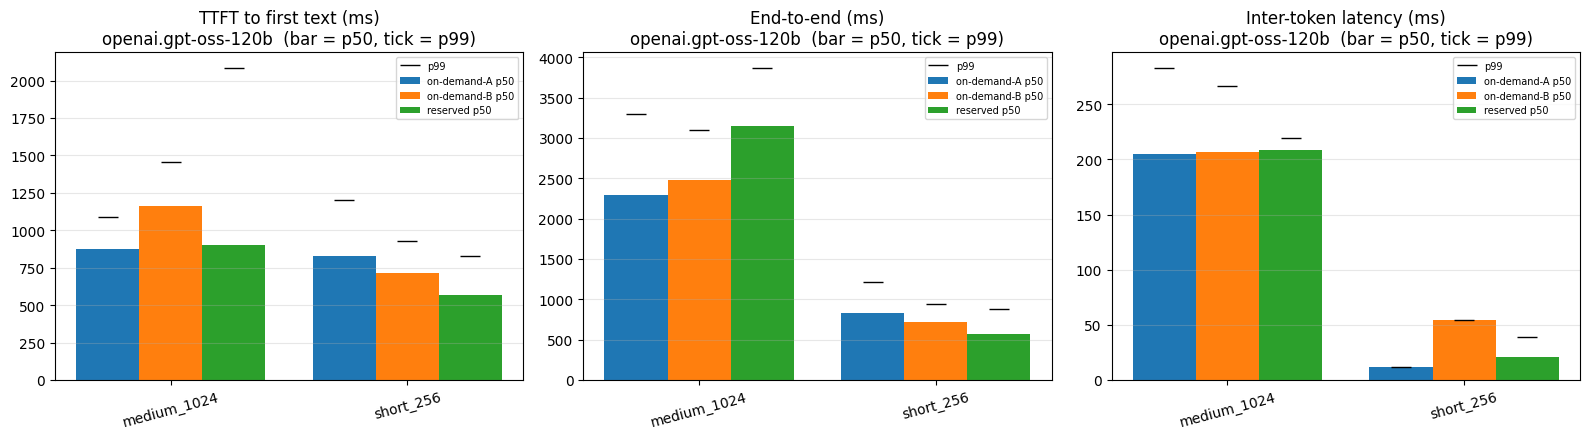

In [14]:
# --- Tier comparison 4/4: aggregate + plot ------------------------------
# Percentiles, not mean +/- sd: the tail is what a reservation is supposed to buy,
# and a mean cannot show one. Three things this reports that the previous version
# could not express:
#   * p50/p90/p95/p99 per arm x scenario, with n;
#   * ITL (inter-token latency) pooled across runs, plus ms-per-output-token, so a
#     difference in output length is not read as a latency win -- in the earlier
#     run the reserved arm generated 12% fewer tokens than standard on medium_1024
#     and that alone shortened its end-to-end time;
#   * the A/A control gap (on-demand-A vs on-demand-B), which is the noise floor
#     any reserved-vs-on-demand claim has to clear.
# The old 'rate_tps' panel is gone: it computed out_tokens / (latency - ttft),
# whose denominator is ~0 whenever the answer arrives in a single delta, and
# reported 18,000 tok/s.
import matplotlib.pyplot as plt

RU_METRICS = [("ttft_text_ms", "ttft_text"), ("ttft_any_ms", "ttft_any"),
              ("e2e_ms", "e2e"), ("ms_per_out_token", "ms_per_tok"),
              ("tpot_ms", "tpot")]

ru_summary = pd.DataFrame()
if len(ru_df) == 0:
    print("ru_df is empty - did the tier benchmark cell run?")
else:
    _ok = ru_df[ru_df["status"] == "ok"]
    _rows = []
    for (arm, scen), g in _ok.groupby(["arm", "scenario"]):
        row = {"arm": arm, "scenario": scen, "n": len(g),
               "out_tokens_mean": g["out_tokens"].mean(),
               "reasoning_tok_mean": g["reasoning_tokens"].mean(),
               "cached_tok_mean": g["cached_tokens"].mean(),
               "deltas_med": g["n_deltas"].median()}
        for col, short in RU_METRICS:
            s = pct_stats(g[col].tolist())
            for q in ("p50", "p90", "p95", "p99"):
                row[f"{short}_{q}"] = s.get(q)
        s_itl = pct_stats([v for lst in g["itls_ms"] for v in lst])
        row["itl_n"] = s_itl.get("n", 0)
        for q in ("p50", "p90", "p99"):
            row[f"itl_{q}"] = s_itl.get(q)
        _rows.append(row)
    ru_summary = pd.DataFrame(_rows).round(1)

    _show = ["arm", "scenario", "n", "ttft_text_p50", "ttft_text_p99", "ttft_any_p50",
             "e2e_p50", "e2e_p99", "ms_per_tok_p50", "itl_n", "itl_p50", "itl_p99",
             "out_tokens_mean", "reasoning_tok_mean", "cached_tok_mean", "deltas_med"]
    print(ru_summary[[c for c in _show if c in ru_summary.columns]].to_string(index=False))

    def _v(short, arm, scen, q):
        sub = ru_summary[(ru_summary["arm"] == arm) & (ru_summary["scenario"] == scen)]
        col = f"{short}_{q}"
        if not len(sub) or col not in sub.columns:
            return float("nan")
        return float(sub[col].iloc[0])

    print("\nnoise floor vs tier effect  (A/A = on-demand-B minus on-demand-A; "
          "tier = reserved minus the mean of the two on-demand arms):")
    for scen in ru_summary["scenario"].unique():
        for short in ("ttft_text", "e2e"):
            for q in ("p50", "p99"):
                a = _v(short, "on-demand-A", scen, q)
                b = _v(short, "on-demand-B", scen, q)
                r = _v(short, "reserved", scen, q)
                aa = b - a
                eff = r - (a + b) / 2
                if eff != eff:
                    verdict = "no reserved arm"
                elif aa != aa:
                    verdict = "no A/A control"
                else:
                    verdict = ("WITHIN the noise floor" if abs(eff) <= abs(aa)
                               else "exceeds the noise floor")
                print(f"  {scen:<12s} {short:<10s} {q}   A/A={aa:+9.1f}ms   "
                      f"tier={eff:+9.1f}ms   ({verdict})")
    print("\nA tier effect that is 'within the noise floor' is not evidence of a "
          "reservation benefit, however large it looks in isolation.")

    _scens = list(ru_summary["scenario"].unique())
    _arms = list(ru_summary["arm"].unique())
    _panels = [("ttft_text", "TTFT to first text (ms)"), ("e2e", "End-to-end (ms)"),
               ("itl", "Inter-token latency (ms)")]
    _x = range(len(_scens))
    _w = 0.8 / max(len(_arms), 1)
    fig, axes = plt.subplots(1, len(_panels), figsize=(16, 4.5))
    for ax, (short, title) in zip(axes, _panels):
        for j, arm in enumerate(_arms):
            p50 = [_v(short, arm, s, "p50") for s in _scens]
            p99 = [_v(short, arm, s, "p99") for s in _scens]
            pos = [i + j * _w for i in _x]
            ax.bar(pos, p50, _w, label=f"{arm} p50")
            ax.plot(pos, p99, "k_", markersize=14,
                    label="p99" if j == 0 else None)
        ax.set_xticks([i + _w * (len(_arms) - 1) / 2 for i in _x])
        ax.set_xticklabels(_scens, rotation=15)
        ax.set_title(f"{title}\n{RU_MODEL}  (bar = p50, tick = p99)")
        ax.legend(fontsize=7)
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

###  On-demand (default tier) TPM ceiling — gpt-oss-120b ONLY 

Measures the highest sustained tokens-per-minute the STANDARD on-demand tier
delivers *without throttling or queuing*, across the same three window sizes
the benchmark cells above use (short_256 / medium_1024 / long_2048).

 "gpt-oss-120b only": exactly one model, no sweep (contrast the benchmark cell
   above, which walks five). TPM_MODEL is pinned to the literal below rather
   than read from RU_MODEL, so retargeting the config cell — which supports
   other models, hence its google.gemma-4 path branch — cannot silently point
   this measurement at something else. TPM_BASE_PATH is gpt-oss's route.

In [15]:
# --- On-demand (default tier) TPM ceiling — gpt-oss-120b ONLY ---------------
# "on-demand": no openai-project header on any request here, so nothing can be
#   matched to a reservation. The warmup call below asserts this by showing that
#   no x-amzn-usage-reservation-* headers come back. Because this cell runs after
#   teardown it is also the "no header, no reservation" quadrant of the routing
#   2x2 in the negative-control cell above.
# "without throttling": the client is built with max_retries=0 — the SDK default
#   of 2 would silently retry a 429 with backoff, which is precisely the
#   client-side throttling this measurement must not contain. There is no rate
#   limiter and no retry/backoff queue anywhere in the harness.
# "without queuing": queuing is detected rather than tolerated. A step whose
#   median TTFT inflates past TPM_QUEUE_FACTOR x the concurrency-1 baseline is
#   server-side queued, so it does not count toward the ceiling.
#
# Per window size, concurrency ramps up until a step throttles, errors or queues;
# the ceiling is the best TPM among the steps that stayed clean. Runtime scales
# with the ramp — worst case sum(TPM_CONCURRENCY_STEPS) * TPM_REQS_PER_WORKER
# requests per window, so lower TPM_REQS_PER_WORKER for a quick pass.
#
# The per-step numbers now come from the shared harness (sweep_arm/stream_bench),
# so this sweep reports the same percentiles as the tier cells. It previously kept
# only a median TTFT per step, which cannot show a tail.
import pandas as pd
from openai import OpenAI

TPM_MODEL             = "openai.gpt-oss-120b"   # pinned; deliberately not RU_MODEL
TPM_BASE_PATH         = "/v1"                   # gpt-oss's OpenAI-compatible route
TPM_CONCURRENCY_STEPS = [1, 2, 4, 8, 16, 32]
TPM_REQS_PER_WORKER   = 3      # requests per worker at each step (>=2 for steady state)
TPM_QUEUE_FACTOR      = 2.0    # median TTFT > factor x baseline => server-side queuing

_TPM_LONG_BLOCK = "REFERENCE CONTEXT for throughput measurement. " * 250

TPM_WINDOWS = [
    {"name": "short_256", "max_tokens": 256,
     "prompt": "Write one sentence about computing."},
    {"name": "medium_1024", "max_tokens": 1024,
     "prompt": ("Write a paragraph about the history of computing, covering early "
                "mechanical devices, the rise of digital computers, and the modern era.")},
    {"name": "long_2048", "max_tokens": 2048,
     "prompt": (_TPM_LONG_BLOCK + "\n\nBased on the reference context above, write a "
                "comprehensive paragraph about the history of computing.")},
]

tpm_client = OpenAI(
    api_key=RU_TOKEN,
    base_url=f"{MANTLE_ENDPOINT}{TPM_BASE_PATH}",
    max_retries=0,   # do not retry 429s — see header comment
    timeout=SDK_TIMEOUT_S,   # SDK-level: a custom http_client's timeout is ignored
    http_client=logging_http_client(),   # INVOCATION_LOG capture (config cell)
)

# Warmup on the same path, and proof we are on the on-demand tier.
_st, _hdrs, _ = mantle_request(
    "POST", f"{TPM_BASE_PATH}/chat/completions",
    body={"model": TPM_MODEL, "max_tokens": 16,
          "messages": [{"role": "user", "content": "warmup"}]},
)
print(f"warmup HTTP {_st}  reservation headers: "
      f"{reservation_headers(_hdrs) or '(none -> on-demand / default tier)'}")


def _r1(v):
    """round(v, 1) that survives None and NaN."""
    return round(v, 1) if isinstance(v, (int, float)) and v == v else None


tpm_steps, tpm_reqs, tpm_ceilings = [], [], []
for w in TPM_WINDOWS:
    steps, reqs = sweep_arm(
        tpm_client, arm=f"tpm-ceiling/{w['name']}", tier_intent="on-demand",
        project=None, model=TPM_MODEL, window=w,
        conc_steps=TPM_CONCURRENCY_STEPS, reqs_per_worker=TPM_REQS_PER_WORKER,
        queue_factor=TPM_QUEUE_FACTOR, stop_when_dirty=True)
    tpm_steps += steps
    tpm_reqs += reqs

    clean = [s for s in steps if s["clean"]]
    broke_at = next((s["concurrency"] for s in steps if not s["clean"]), None)
    if clean:
        best = max(clean, key=lambda s: s["total_tpm"])
        tail = (f"broke at conc={broke_at}" if broke_at
                else "never broke — raise TPM_CONCURRENCY_STEPS to find the real ceiling")
        print(f"    -> clean TPM ceiling = {best['total_tpm']:,.0f} total "
              f"({best['out_tpm']:,.0f} output, {best['blended_tpm']:,.0f} blended) "
              f"at conc={best['concurrency']};  {tail}")
        tpm_ceilings.append({
            "window": w["name"], "max_tokens": w["max_tokens"],
            "clean_conc": best["concurrency"], "broke_at_conc": broke_at,
            "total_tpm": round(best["total_tpm"]), "out_tpm": round(best["out_tpm"]),
            "blended_tpm": round(best["blended_tpm"]),
            "ttft_p50_ms": _r1(best.get("ttft_p50")),
            "ttft_p99_ms": _r1(best.get("ttft_p99")),
            "e2e_p99_ms": _r1(best.get("e2e_p99")),
            "itl_p50_ms": _r1(best.get("itl_p50")),
            "itl_p99_ms": _r1(best.get("itl_p99")),
        })
    else:
        print("    -> no clean step: even conc=1 throttled or errored (see rows above)")

tpm_df = pd.DataFrame(tpm_steps)
tpm_req_df = pd.DataFrame(tpm_reqs)
tpm_ceiling_df = pd.DataFrame(tpm_ceilings)

print("\n" + "=" * 96)
print(f"On-demand (default tier) TPM ceiling — {TPM_MODEL} @ {RU_REGION}")
print("no openai-project header, no service_tier, max_retries=0, no client-side "
      "rate limiter/queue")
print("=" * 96)
if len(tpm_ceiling_df):
    print(tpm_ceiling_df.to_string(index=False))
    _cap = RU_CATALOG[TPM_MODEL]["tpm_per_ru"]
    _best_blended = tpm_ceiling_df["blended_tpm"].max()
    print(f"\nreserved-tier reference: 1 RU = {_cap:,} blended TPM.  "
          f"best clean on-demand blended = {_best_blended:,} "
          f"({_best_blended / _cap:.2f} RU-equivalent)")
else:
    print("no clean measurements collected.")

_show = ["window", "concurrency", "requests", "ok", "throttled_429", "errors",
         "elapsed_s", "total_tpm", "blended_tpm", "ttft_p50", "ttft_p90", "ttft_p99",
         "e2e_p99", "itl_p50", "itl_p99", "ttft_ratio", "queued", "clean"]
tpm_df[[c for c in _show if c in tpm_df.columns]].round(1) if len(tpm_df) else tpm_df

warmup HTTP 200  reservation headers: (none -> on-demand / default tier)

  === arm=tpm-ceiling/short_256  window=short_256  max_tokens=256  addressed to on-demand ===
    conc=1   req=3    ok=3    429=0   err=0      3.1s  blended=    32,722  ttft p50=    757 p99=   1627ms  e2e p99=    1632ms  hdrs=0/3 spill=0  ok
    conc=2   req=6    ok=6    429=0   err=0      3.0s  blended=    67,919  ttft p50=    953 p99=   1119ms  e2e p99=    1124ms  hdrs=0/6 spill=0  ok
    conc=4   req=12   ok=12   429=0   err=0      3.2s  blended=   121,788  ttft p50=    900 p99=   1514ms  e2e p99=    1521ms  hdrs=0/12 spill=0  ok
    conc=8   req=24   ok=24   429=0   err=0      3.1s  blended=   251,388  ttft p50=    799 p99=   1523ms  e2e p99=    1530ms  hdrs=0/24 spill=0  ok
    conc=16  req=48   ok=48   429=0   err=0      3.5s  blended=   465,359  ttft p50=    861 p99=   1627ms  e2e p99=    1859ms  hdrs=0/48 spill=0  ok
    conc=32  req=96   ok=96   429=0   err=0      3.5s  blended=   965,593  ttft p50=    8

,window,concurrency,requests,ok,throttled_429,errors,elapsed_s,total_tpm,blended_tpm,ttft_p50,ttft_p90,ttft_p99,e2e_p99,itl_p50,itl_p99,ttft_ratio,queued,clean
0,short_256,1,3,3,0,0,3.1,12137.7,32721.6,757.0,1626.5,1626.5,1631.7,NaN,NaN,1.0,False,True
1,short_256,2,6,6,0,0,3.0,25222.9,67918.7,953.4,1095.4,1119.0,1124.3,NaN,NaN,1.3,False,True
2,short_256,4,12,12,0,0,3.2,45587.2,121787.7,899.6,1071.9,1513.7,1521.0,NaN,NaN,1.2,False,True
3,short_256,8,24,24,0,0,3.1,94787.4,251388.4,799.4,1258.0,1522.9,1529.5,NaN,NaN,1.1,False,True
4,short_256,16,48,48,0,0,3.5,172761.5,465358.9,860.8,1291.1,1627.2,1859.2,13.5,90.4,1.1,False,True
5,short_256,32,96,96,0,0,3.5,354867.0,965592.9,873.5,1317.1,1694.8,1846.2,13.2,106.2,1.2,False,True
6,medium_1024,1,3,3,0,0,4.6,14504.5,44762.7,486.8,818.2,818.2,2176.6,204.4,218.2,1.0,False,True
7,medium_1024,2,6,6,0,0,5.0,28141.2,88257.8,636.5,657.6,1067.5,1994.6,204.4,247.3,1.3,False,True
8,medium_1024,4,12,12,0,0,6.8,45535.7,146367.1,730.3,927.9,1599.1,3589.5,205.2,215.1,1.5,False,True
9,medium_1024,8,24,24,0,0,7.6,77674.1,247292.8,872.4,1295.4,1884.2,3164.2,204.7,241.6,1.8,False,True


### Step 6: adjust the reservation

Changes take effect immediately — no cooldown, no re-commitment. Drive this from the
`EquivalentReservationUnits` CloudWatch metric (namespace `AWS/BedrockMantle`, dimensions
model ID + project ID) over a multi-day window: sustained spillover above ~5% means scale up,
consistently below 50% of purchased RUs means scale down.

> The preview doc writes the update/cancel path as `/bedrock/v1/$RESERVATIONS_ID`, dropping the
> `reservations` segment used by POST and GET. Assumed to be a typo — the cells below use
> `/bedrock/v1/reservations/{id}`. If you get a 404, try the doc's literal path.


In [16]:
# --- Step 6: scale the reservation up/down (BILLABLE) --------------------
# Routed through scale_reservation() (config cell) so the RU_MAX_QUANTITY ceiling
# is enforced in exactly one place: a request above it is clamped, not rejected,
# and RU_QUANTITY is only updated after the API confirms the change. The default
# reservation size is RU_QUANTITY = 2; the routing-evidence cell auto-scales toward
# RU_MAX_QUANTITY = 4 on its own when a ramp saturates, so this cell is the manual
# override.
RU_NEW_QUANTITY = 4          # clamped to RU_MAX_QUANTITY

if RESERVATION_ID:
    spec = RU_CATALOG[RU_MODEL]
    print(f"current : {RU_QUANTITY} RU = {RU_QUANTITY * spec['tpm_per_ru']:,} blended "
          f"TPM (${RU_QUANTITY * spec['usd_per_ru_hour']:.2f}/hour)")
    print(f"ceiling : {RU_MAX_QUANTITY} RU = "
          f"{RU_MAX_QUANTITY * spec['tpm_per_ru']:,} blended TPM "
          f"(${RU_MAX_QUANTITY * spec['usd_per_ru_hour']:.2f}/hour)\n")
    scale_reservation(RU_NEW_QUANTITY)
    _st, _h, _b = mantle_request(
        "GET", f"/bedrock/v1/reservations/{RESERVATION_ID}", project=PROJECT_ID)
    show(_st, _h, _b)
else:
    print("no RESERVATION_ID in this kernel — run the discovery cell (Step 3c) to find "
          "and\nadopt an existing reservation, or create one via Step 3a.")


no RESERVATION_ID in this kernel — run the discovery cell (Step 3c) to find and
adopt an existing reservation, or create one via Step 3a.


### Step 7: cancel — final safety net

**Billing continues until you cancel.** The first hour is always billed in full; after that it
stops immediately. The perf-test teardown cell already cancels, so this normally reports
*CLEAN*. It sweeps every project in every region in `RU_DISCOVER_REGIONS` and cancels anything
still active or pending — run it last, every session.


In [17]:
# --- Step 7: cancel — final safety net -----------------------------------
# Cancels the tracked reservation, then sweeps EVERY project in EVERY region in
# RU_DISCOVER_REGIONS and cancels anything still active/pending. Not gated by
# CONFIRM_SPEND: teardown must always be possible, including after a kernel
# restart. Run this last, every session.
RU_CANCEL_EVERYTHING = True

if RESERVATION_ID:
    cancel_reservation(RESERVATION_ID)
    RESERVATION_ID = None
else:
    print("no RESERVATION_ID tracked in this kernel — sweeping for leftovers instead.")

# One unscoped list per region, each reservation paired with its OWNING project
# (see res_project_id). The previous project-loop pairing 404'd on every cancel.
leftovers = []
for region in RU_DISCOVER_REGIONS:
    names = {p["id"]: p.get("name") for p in list_projects(region)}
    items, _ = list_reservations(None, region)
    for res in items:
        if str(res.get("status", "")).lower() in ("active", "pending"):
            owner = res_project_id(res)
            leftovers.append((region, owner,
                              names.get(owner, "NOT LISTED (archived)"), res))

print()
if not leftovers:
    print(f"CLEAN — nothing active or pending in {RU_DISCOVER_REGIONS}. Nothing is billing.")
elif RU_CANCEL_EVERYTHING:
    print(f"cancelling {len(leftovers)} leftover reservation(s):")
    for region, owner, owner_name, res in leftovers:
        print(f"  {region} / {owner_name} [{owner}] / {res['id']} ({res.get('status')})")
        cancel_reservation(res["id"], project=owner, region=region)
    print("\nre-checking:")
    still = [(r, res_project_id(x), x["id"]) for r in RU_DISCOVER_REGIONS
             for x in list_reservations(None, r)[0]
             if str(x.get("status", "")).lower() in ("active", "pending")]
    print(f"  {'STILL BILLING: ' + str(still) if still else 'CLEAN — nothing is billing.'}")
else:
    print(f"STILL BILLING ({len(leftovers)}) — RU_CANCEL_EVERYTHING is False:")
    for region, owner, owner_name, res in leftovers:
        print(f"  {region} / {owner_name} [{owner}] / {res['id']} ({res.get('status')})")

no RESERVATION_ID tracked in this kernel — sweeping for leftovers instead.

CLEAN — nothing active or pending in ['us-east-1', 'us-east-2', 'us-west-2']. Nothing is billing.


In [18]:
# --- Appendix: archived projects — inspect, archive, and why DELETE is absent ---
# GOAL: "delete an archived project by project ID". The Mantle API does not
# support deleting a project at all. Probed against the live endpoint:
#
#   DELETE /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#   PUT    /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#   PATCH  /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#
# The Allow header is the authoritative answer: only GET/HEAD/POST exist on that
# resource. There is no alternate route either — these all 404:
#   DELETE /bedrock/v1/projects/{id}
#   DELETE /v1/projects/{id}
#   POST   /v1/organization/projects/{id}/delete
#
# So archiving is TERMINAL. POST .../archive is the only lifecycle mutation, and
# an archived project then rejects everything with "is archived and does not
# support mutating operations" — the HTTP 400 that broke Step 4.
#
# There is also no `aws` CLI surface: aws-cli 2.33.14 has no `bedrock-mantle`
# service and `aws bedrock` exposes no project commands. Mantle authenticates
# with a Bearer token rather than SigV4, so plain curl IS the CLI form here
# (same approach as the data-retention cell near the top of this notebook).
#
# This cell therefore does the two things that ARE possible:
#   1. list every project INCLUDING archived  (list_projects() above hides them)
#   2. archive an ACTIVE project by id        (set MANTLE_ARCHIVE_PROJECT_ID)
# plus it flags archived projects that still own active reservations, which is
# the trap worth avoiding: archiving a project does NOT cancel its reservations,
# and afterwards the project is invisible to a list_projects() sweep, so those
# reservations keep billing and are easy to lose track of.

MANTLE_ARCHIVE_PROJECT_ID = None   # e.g. "proj_xxxxxxxx" — ARCHIVES it, not undoable

# --- 1. list every project, archived included -------------------------------
# include_archived=true is the key parameter; without it archived projects are
# invisible. CLI form:
print("$ curl -s -X GET \\")
print(f"    '{MANTLE_ENDPOINT}/v1/organization/projects?include_archived=true' \\")
print('    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" | python3 -m json.tool')
print()

!curl -s -X GET "{MANTLE_ENDPOINT}/v1/organization/projects?include_archived=true" \
      -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" \
      -o /tmp/mantle_projects.json -w 'HTTP %{{http_code}}\n'
# NB: braces are doubled on purpose. IPython expands {...} in a ! line, so a bare
# %{http_code} gets eaten and curl silently reports 000 instead of the real code.

import json as _json
with open("/tmp/mantle_projects.json") as _f:
    _projects = (_json.load(_f) or {}).get("data", [])

_archived = [p for p in _projects
             if p.get("status") == "archived" or p.get("archived_at")]
print(f"\n{len(_projects)} project(s), {len(_archived)} archived\n")
print(f"{'project id':30} {'name':40} {'status':9} archived_at")
print("-" * 100)
for _p in sorted(_projects, key=lambda x: (x.get("status") != "active", x.get("id", ""))):
    _at = _p.get("archived_at")
    _when = time.strftime("%Y-%m-%d %H:%M", time.localtime(_at)) if _at else ""
    print(f"{_p.get('id',''):30} {(_p.get('name') or '')[:40]:40} "
          f"{_p.get('status',''):9} {_when}")

# --- 2. archived projects that still own active reservations ---------------
# These are the expensive ones: still billing, and unreachable by any sweep that
# iterates list_projects(). Cancel them with the reservation's OWNING project id
# (Step 7 does this correctly now via res_project_id).
_arch_ids = {p["id"] for p in _archived}
_stuck = []
for _region in RU_DISCOVER_REGIONS:
    for _res in list_reservations(None, _region)[0]:
        if (str(_res.get("status", "")).lower() in ("active", "pending")
                and res_project_id(_res) in _arch_ids):
            _stuck.append((_region, res_project_id(_res), _res))

if _stuck:
    print(f"\n!! {len(_stuck)} active reservation(s) owned by ARCHIVED projects — "
          f"still billing:")
    for _region, _owner, _res in _stuck:
        print(f"   {_region} / {_owner} / {_res['id']} ({_res.get('status')})")
    print("   Cancel via Step 7, or directly:")
    for _region, _owner, _res in _stuck:
        print(f"   $ curl -s -X DELETE "
              f"'https://bedrock-mantle.{_region}.api.aws"
              f"/bedrock/v1/reservations/{_res['id']}' \\")
        print(f"       -H \"Authorization: Bearer $BEDROCK_MANTLE_TOKEN\" \\")
        print(f"       -H 'openai-project: {_owner}'")
else:
    print("\nno active reservations owned by archived projects — clean.")

# --- 3. archive an ACTIVE project by id (the only supported retire path) -----
if MANTLE_ARCHIVE_PROJECT_ID:
    _path = f"/v1/organization/projects/{MANTLE_ARCHIVE_PROJECT_ID}/archive"
    print(f"\n$ curl -s -X POST '{MANTLE_ENDPOINT}{_path}' \\")
    print('    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN"')
    # Refuse to orphan a live reservation.
    _own = [r for r in list_reservations(None, RU_REGION)[0]
            if res_project_id(r) == MANTLE_ARCHIVE_PROJECT_ID
            and str(r.get("status", "")).lower() in ("active", "pending")]
    if _own:
        print(f"\nREFUSED: {MANTLE_ARCHIVE_PROJECT_ID} still owns "
              f"{len(_own)} active/pending reservation(s): "
              f"{[r['id'] for r in _own]}")
        print("Cancel those first — archiving now would leave them billing and "
              "unreachable by a project sweep.")
    else:
        _st, _, _b = mantle_request("POST", _path)
        show(_st, {}, _b, max_chars=600)
else:
    print("\nMANTLE_ARCHIVE_PROJECT_ID is None — nothing archived (no-op).")
    print("Set it to a proj_... id to archive that project. Deleting is not "
          "possible: DELETE returns 405, Allow: GET,HEAD,POST.")

$ curl -s -X GET \
    'https://bedrock-mantle.us-east-1.api.aws/v1/organization/projects?include_archived=true' \
    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" | python3 -m json.tool

HTTP 200

13 project(s), 11 archived

project id                     name                                     status    archived_at
----------------------------------------------------------------------------------------------------
default                        default                                  active    
proj_7yd43zsemo4w7zpyihsu      mantle-ru-perf-082701                    active    
proj_3bpzlcnpmyswqyqx2qct      mantle-ru-perf-0820                      archived  2026-08-27 20:39
proj_4yb543xi24rnsesnv3dw      mantle-ru-preview-0821                   archived  2026-08-20 22:00
proj_bcqsgq4deg327t7ell3m      mantle-ru-perf3                          archived  2026-07-29 15:08
proj_djqczs66bwwhsfiavhkx      mantle-ru-perf-0820                      archived  2026-08-20 22:00
proj_dxggwtp2

## Invocation logs + CloudWatch logs → markdown report

Everything the notebook did, logged from both sides, then saved as one markdown file
under `reports/`:

1. **Client-side Mantle API invocation log** — every HTTP call made in this kernel
   (raw `mantle_request()` calls *and* OpenAI-SDK calls, captured by an httpx hook in the
   config cell), each with a best-effort `handled_by` attribution from the
   `x-amzn-usage-reservation-*` response headers: quota headers ⇒ **reservation (RU)**,
   spillover header ⇒ **on-demand pool**. The preview does not always return these headers
   on reserved-tier calls (Step 4 above shows "(none returned)"), so those rows read
   `indeterminate` — the CloudWatch metrics are the authoritative routing signal.
2. **CloudWatch** — `AWS/BedrockMantle` metrics over this session's window:
   `BurnDownConsumed` > 0 ⇒ tokens served from **reservation units**;
   `SpillOverTokenCount` > 0 ⇒ reserved-tier requests served by the **on-demand pool**;
   `EquivalentReservationUnits` = RU utilisation. Queried per `Project` dimension
   (`default` vs the RU project), but the preview has been observed publishing all of it
   under `default` — so the routing verdict sums across projects. Plus Bedrock
   **model-invocation log events** if a CloudWatch log group is configured (checked).
3. **Markdown report** — writes `reports/mantle_oss_ru3_logs_<runid>.md`.

All three cells are read-only against Mantle and safe to run after teardown (CloudWatch
data persists). Metric publication lags 1–3 minutes — if the CloudWatch tables come back
empty right after the benchmark, wait a moment and re-run cells 2 and 3.

In [19]:
# --- Logs 1/3: client-side Mantle API invocation log -----------------------
# INVOCATION_LOG (config cell) captured every Mantle HTTP call this kernel made
# — raw mantle_request() calls and OpenAI-SDK calls alike. Render it with the
# per-request handled_by attribution (on-demand pool vs reservation units).
import pandas as pd

inv_df = pd.DataFrame(INVOCATION_LOG)
if len(inv_df) == 0:
    print("INVOCATION_LOG is empty — run the config cell first, then the "
          "benchmark cells above.")
else:
    for c in ("in_tokens", "out_tokens", "latency_ms"):
        inv_df[c] = pd.to_numeric(inv_df[c], errors="coerce")
    inv_df = inv_df.sort_values("epoch").reset_index(drop=True)

    _inf_mask = inv_df["path"].str.endswith(("/chat/completions", "/responses"))
    print(f"{len(inv_df)} Mantle API calls logged "
          f"({int(_inf_mask.sum())} inference, {int((~_inf_mask).sum())} "
          f"control-plane), {inv_df['ts_utc'].min()} -> {inv_df['ts_utc'].max()} UTC\n")

    print("calls by endpoint x status:")
    print(inv_df.groupby(["method", "path", "status"]).size().to_string(), "\n")

    inv_inf = inv_df[_inf_mask]
    if len(inv_inf):
        print("inference calls by handled_by — client-side view. 'indeterminate' "
              "rows carried the\nopenai-project header but no reservation headers "
              "came back (preview behaviour);\nthe CloudWatch cell below settles "
              "those via BurnDownConsumed / SpillOverTokenCount:")
        print(inv_inf.groupby("handled_by")
              .agg(calls=("path", "count"), in_tokens=("in_tokens", "sum"),
                   out_tokens=("out_tokens", "sum"))
              .to_string(), "\n")
        _spill = int((inv_inf["spillover"].fillna("") == "standard").sum())
        print(f"spillover responses: {_spill}/{len(inv_inf)}")

inv_df.tail(15)

1780 Mantle API calls logged (1753 inference, 27 control-plane), 2026-08-28 02:58:56 -> 2026-08-28 03:31:03 UTC

calls by endpoint x status:
method  path                                                           status
DELETE  /bedrock/v1/reservations/res_1ffacf795dd642d294b106e19a388554  200          1
GET     /bedrock/v1/reservations                                       200         10
        /bedrock/v1/reservations/res_1ffacf795dd642d294b106e19a388554  200          6
        /v1/organization/projects                                      200          7
POST    /bedrock/v1/reservations                                       201          1
        /v1/chat/completions                                           200          4
        /v1/organization/projects                                      200          1
        /v1/responses                                                  200       1749
PUT     /bedrock/v1/reservations/res_1ffacf795dd642d294b106e19a388554  200          1 

infer

,ts_utc,epoch,source,method,path,status,request_id,project,model,in_tokens,out_tokens,quota,remaining_quota,spillover,handled_by,latency_ms
1765,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_fzrbcafgsqpzuotlwsub5jiaxp4yghxxwzd5lv6tbh...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,401.1
1766,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_cqhxoqnvsgzsmkvmzvn7kuap763bhucwlothnoxhv6...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,264.0
1767,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_23hm6e66darjwf2b6eiqasydjgszhtmhgfjvz7yfa4...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,399.4
1768,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_aunyzuytz6enevpc7s5r5kgazr4glaqofawfxw2ybm...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,369.7
1769,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_v2s375wjuad7ov25hvt6jb3gyqaezt6vlmruqlebqf...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,380.6
1770,2026-08-28 03:24:56,1.787887e+09,sdk,POST,/v1/responses,200,req_ilvtw52uqkgqunohmgaxbmghn23bs2wccfj3rrd7ez...,,openai.gpt-oss-120b,NaN,NaN,NaN,NaN,None,on-demand,239.0
1771,2026-08-28 03:30:54,1.787888e+09,raw,GET,/v1/organization/projects,200,req_b2gapgdlcktluuxqmgcrrigil3idlxru5ecxzbtsvg...,,,NaN,NaN,NaN,NaN,None,,295.7
1772,2026-08-28 03:30:55,1.787888e+09,raw,GET,/bedrock/v1/reservations,200,req_3ru57s7ag2umie3qlw67ufu4eqd2hfqcfmrhwrqi5h...,,,NaN,NaN,NaN,NaN,None,,454.0
1773,2026-08-28 03:30:55,1.787888e+09,raw,GET,/v1/organization/projects,200,req_pev4zb5wgirgxnfxejqo6y35leo2wnur2sa6xxoxkw...,,,NaN,NaN,NaN,NaN,None,,289.8
1774,2026-08-28 03:30:55,1.787888e+09,raw,GET,/bedrock/v1/reservations,200,req_pdo2fjz44vzcnxanucbu5iwgvrkboyujx4f5oak64n...,,,NaN,NaN,NaN,NaN,None,,343.5


In [20]:
# --- Logs 2/3: CloudWatch — AWS/BedrockMantle metrics + invocation log events
# Server-side view of the same session: BurnDownConsumed = blended tokens billed
# against reservation units, SpillOverTokenCount = reserved-tier tokens served by
# the on-demand pool, EquivalentReservationUnits = RU-equivalents consumed.
#
# This cell only FETCHES. Attribution and the routing verdict are the NEXT cell:
# everything here is a window total over all traffic, and taking that as a routing
# signal is what made the 20260827_221333 report claim 1,138,666 blended tokens of
# RU burn while the reservation had been deleted 2.5 minutes earlier.
#
# The Project dimension SHOULD split standard ("default") from reserved-tier
# traffic (the RU project id), but the current preview has been observed
# publishing all usage AND reservation metrics under Project="default" — the
# RU project's row came back all-zero while BurnDownConsumed clearly tracked
# the reservation windows. Both projects are still queried and shown, but the
# routing verdict sums the metrics ACROSS projects rather than trusting the
# split.
#
# Read-only and safe after teardown. CloudWatch publication lags 1-3 minutes —
# empty tables right after the benchmark just mean "re-run this cell shortly".
import datetime as dt
import re

import boto3
import pandas as pd

CW_AWS_PROFILE = None      # None => ambient credentials; or e.g. "default"
CW_PERIOD      = 60        # seconds per bucket — session windows are short

# Window: first logged invocation -> now, padded. Fallback: trailing 2 hours.
if INVOCATION_LOG:
    CW_START = (dt.datetime.fromtimestamp(min(e["epoch"] for e in INVOCATION_LOG),
                                          dt.timezone.utc) - dt.timedelta(minutes=5))
else:
    CW_START = dt.datetime.now(dt.timezone.utc) - dt.timedelta(hours=2)
CW_END = dt.datetime.now(dt.timezone.utc) + dt.timedelta(minutes=2)

CW_SUM_METRICS = ["Inferences", "InputTokens", "OutputTokens",
                  "BurnDownConsumed", "SpillOverTokenCount", "InferenceClientErrors"]
CW_AVG_METRICS = ["BurnDownRemaining", "EquivalentReservationUnits"]
CW_PROJECTS = [p for p in ("default", PROJECT_ID) if p]
# The TPM-ceiling cell deliberately pins TPM_MODEL instead of RU_MODEL, so
# query both — otherwise retargeting RU_MODEL silently drops the TPM traffic.
CW_MODELS = sorted({RU_MODEL} | ({TPM_MODEL} if "TPM_MODEL" in globals() else set()))

cw_df, cw_status = pd.DataFrame(), ""
try:
    cw_session = (boto3.Session(profile_name=CW_AWS_PROFILE) if CW_AWS_PROFILE
                  else boto3.Session())
    cw = cw_session.client("cloudwatch", region_name=RU_REGION)
    _acct = cw_session.client("sts", region_name=RU_REGION).get_caller_identity()
    cw_status = f"account {_acct['Account']} @ {RU_REGION}"
    print(f"CloudWatch: {cw_status}")
    print(f"window    : {CW_START:%Y-%m-%d %H:%M} -> {CW_END:%H:%M} UTC, "
          f"period {CW_PERIOD}s")
    print(f"projects  : {CW_PROJECTS}   models: {CW_MODELS}\n")

    queries, qmeta = [], {}
    for pid in CW_PROJECTS:
      for mdl in CW_MODELS:
        dims = [{"Name": "Model", "Value": mdl},
                {"Name": "Project", "Value": pid}]
        for name, stat in ([(m, "Sum") for m in CW_SUM_METRICS]
                           + [(m, "Average") for m in CW_AVG_METRICS]):
            qid = f"q{len(queries)}"
            queries.append({"Id": qid, "ReturnData": True, "MetricStat": {
                "Metric": {"Namespace": "AWS/BedrockMantle", "MetricName": name,
                           "Dimensions": dims},
                "Period": CW_PERIOD, "Stat": stat}})
            qmeta[qid] = (pid, mdl, name, stat)

    rows, token = [], None
    while True:
        kw = dict(MetricDataQueries=queries, StartTime=CW_START, EndTime=CW_END,
                  ScanBy="TimestampAscending")
        if token:
            kw["NextToken"] = token
        resp = cw.get_metric_data(**kw)
        for r in resp["MetricDataResults"]:
            pid, mdl, name, stat = qmeta[r["Id"]]
            rows += [{"ts": t, "project": pid, "model": mdl, "metric": name,
                      "stat": stat, "value": v}
                     for t, v in zip(r["Timestamps"], r["Values"])]
        token = resp.get("NextToken")
        if not token:
            break
    cw_df = pd.DataFrame(rows)
except Exception as e:
    cw_status = f"UNAVAILABLE — {type(e).__name__}: {e}"
    print(f"CloudWatch metrics {cw_status}")

cw_summary, cw_routing = pd.DataFrame(), pd.DataFrame()
if len(cw_df):
    cw_df["ts"] = pd.to_datetime(cw_df["ts"], utc=True)
    _sums = cw_df[cw_df.stat == "Sum"].pivot_table(
        index=["project", "model"], columns="metric", values="value", aggfunc="sum")
    _avgs = cw_df[cw_df.stat == "Average"].pivot_table(
        index=["project", "model"], columns="metric", values="value", aggfunc="mean")
    cw_summary = _sums.join(_avgs, how="outer").fillna(0).round(3).sort_index()
    cw_summary = cw_summary[[c for c in CW_SUM_METRICS + CW_AVG_METRICS
                             if c in cw_summary.columns]]
    print("totals per project x model over the window "
          "(Sum metrics summed, Average metrics averaged):")
    print(cw_summary.to_string(), "\n")

    _burn = (float(cw_summary["BurnDownConsumed"].sum())
             if "BurnDownConsumed" in cw_summary else 0.0)
    _spill = (float(cw_summary["SpillOverTokenCount"].sum())
              if "SpillOverTokenCount" in cw_summary else 0.0)
    print("raw totals over the query window, summed across Project dimension "
          "values.")
    print("NOT a routing verdict — the attribution cell below is:")
    print(f"  BurnDownConsumed    : {_burn:,.0f} blended tokens")
    print(f"  SpillOverTokenCount : {_spill:,.0f} tokens")
    print("  These are window totals over ALL traffic. In the 20260827_221333 run")
    print("  BurnDownConsumed came to 1,138,666 = input + 4 x output for every")
    print("  request in the window, including 568 issued after the reservation had")
    print("  been deleted — so on its own it attributes nothing. The next cell")
    print("  attributes it per arm using the quiet-gap minute buckets.")

    _rt = cw_df[cw_df.metric.isin(["BurnDownConsumed", "SpillOverTokenCount"])
                & (cw_df.value > 0)]
    if len(_rt):
        cw_routing = (_rt.pivot_table(index=["ts", "project", "model"],
                                      columns="metric",
                                      values="value", aggfunc="sum")
                      .fillna(0).reset_index())
        cw_routing["ts"] = cw_routing["ts"].dt.strftime("%Y-%m-%d %H:%M")
        print("\nnon-zero routing buckets (RU burn vs spillover, per minute):")
        print(cw_routing.to_string(index=False))
    else:
        print("\nno non-zero BurnDownConsumed / SpillOverTokenCount buckets in the "
              "window.")
elif not cw_status.startswith("UNAVAILABLE"):
    print("no AWS/BedrockMantle datapoints in the window "
          "(publication lags 1-3 min — re-run this cell shortly).")

# --- CloudWatch LOG EVENTS (Bedrock model-invocation logging), if configured --
cw_log_events, cw_log_status, cw_log_groups = [], "", []
try:
    _cfg = (cw_session.client("bedrock", region_name=RU_REGION)
            .get_model_invocation_logging_configuration().get("loggingConfig")) or {}
    _lg = (_cfg.get("cloudWatchConfig") or {}).get("logGroupName")
    cw_log_status = (f"ENABLED, log group {_lg}" if _lg else
                     ("ENABLED (non-CloudWatch destination)" if _cfg
                      else "NOT ENABLED"))
    logs_client = cw_session.client("logs", region_name=RU_REGION)
    cw_log_groups = [_lg] if _lg else []
    for page in logs_client.get_paginator("describe_log_groups").paginate():
        for g in page["logGroups"]:
            if (re.search(r"bedrock|mantle", g["logGroupName"], re.I)
                    and g["logGroupName"] not in cw_log_groups):
                cw_log_groups.append(g["logGroupName"])
    print(f"\nmodel-invocation logging: {cw_log_status}")
    print(f"candidate log groups: {cw_log_groups or '(none matching bedrock/mantle)'}")
    for _grp in cw_log_groups:
        try:
            for page in logs_client.get_paginator("filter_log_events").paginate(
                    logGroupName=_grp,
                    startTime=int(CW_START.timestamp() * 1000),
                    endTime=int(CW_END.timestamp() * 1000),
                    PaginationConfig={"MaxItems": 200}):
                for ev in page.get("events", []):
                    cw_log_events.append({
                        "ts_utc": dt.datetime.fromtimestamp(
                            ev["timestamp"] / 1000, dt.timezone.utc
                        ).strftime("%Y-%m-%d %H:%M:%S"),
                        "log_group": _grp,
                        "stream": ev.get("logStreamName", ""),
                        "message": ev["message"].strip()[:500]})
        except Exception as e:
            print(f"  {_grp}: {type(e).__name__}: {e}")
    print(f"log events in window: {len(cw_log_events)}"
          + ("" if cw_log_groups else
             "  — enable model-invocation logging (see the markdown report for "
             "the CLI) to capture request-level logs"))
except Exception as e:
    cw_log_status = f"could not read config ({type(e).__name__}: {e})"
    print(f"\nmodel-invocation logging: {cw_log_status}")

CloudWatch: account 976939723775 @ us-east-1
window    : 2026-08-28 02:53 -> 03:33 UTC, period 60s
projects  : ['default', 'proj_7yd43zsemo4w7zpyihsu']   models: ['openai.gpt-oss-120b']

totals per project x model over the window (Sum metrics summed, Average metrics averaged):
metric                       Inferences  InputTokens  OutputTokens  BurnDownConsumed  InferenceClientErrors  EquivalentReservationUnits
project model                                                                                                                          
default openai.gpt-oss-120b       943.0     475688.0      283049.0         1607884.0                    0.0                       0.005 

raw totals over the query window, summed across Project dimension values.
NOT a routing verdict — the attribution cell below is:
  BurnDownConsumed    : 1,607,884 blended tokens
  SpillOverTokenCount : 0 tokens
  These are window totals over ALL traffic. In the 20260827_221333 run
  BurnDownConsumed came to 1,1

In [21]:
# --- Logs 2b/3: attribute the CloudWatch minutes to the measured arms ------
# Channels 2 and 3 of the routing evidence, and the cell that produces the actual
# routing verdict.
#
# Why it has to work this way: the Project dimension cannot separate the tiers
# (the preview publishes everything under "default"), and the preview returns no
# per-request reservation headers. What is left is TIME -- the routing-evidence
# cell separated the arms with quiet gaps so each owns whole CloudWatch 60s
# buckets. A minute claimed by exactly one tier_intent is attributable; minutes
# shared by two arms (the interleaved latency cell, on purpose) or claimed by no
# arm are reported separately and excluded from the verdict instead of being
# folded into it.
#
# This also fixes two defects in the previous verdict:
#   * it summed the entire query window, which begins 5 minutes BEFORE the first
#     API call -- the 20260827_221333 report silently included a 6,364-token
#     bucket at 22:04, before the run had started;
#   * it called BurnDownConsumed the authoritative routing signal while that
#     metric equalled input + burndown x output for ALL traffic in the window,
#     on-demand included (1,138,666 vs 1,134,130 client-side, 0.16% apart).
import time

import pandas as pd

ROUTING_SUM_METRICS = ["BurnDownConsumed", "SpillOverTokenCount", "Inferences"]
ROUTING_AVG_METRICS = ["EquivalentReservationUnits", "BurnDownRemaining"]

cw_attrib_df = pd.DataFrame()
routing_verdict = {}
routing_notes = []

_owner_tiers, _owner_arms = {}, {}
for _w in ARM_WINDOWS:
    for _min in _w["minutes"]:
        _owner_tiers.setdefault(_min, set()).add(_w["tier_intent"])
        _owner_arms.setdefault(_min, set()).add(_w["arm"])

if not len(cw_df):
    print("no CloudWatch datapoints — run the CloudWatch cell "
          "(publication lags 1–3 min).")
elif not ARM_WINDOWS:
    print("ARM_WINDOWS is empty — run the measurement cells in this kernel, "
          "otherwise there is nothing to attribute the minutes to.")
else:
    _m = cw_df[cw_df["metric"].isin(ROUTING_SUM_METRICS + ROUTING_AVG_METRICS)].copy()
    _m["minute"] = _m["ts"].dt.strftime("%Y-%m-%d %H:%M")
    # Sum the Sum-metrics across the Project dimension (the split is untrustworthy,
    # the per-minute total is not); average the Average-metrics instead of summing,
    # or BurnDownRemaining would be double-counted across projects.
    _p1 = _m[_m["stat"] == "Sum"].pivot_table(
        index="minute", columns="metric", values="value", aggfunc="sum")
    _p2 = _m[_m["stat"] == "Average"].pivot_table(
        index="minute", columns="metric", values="value", aggfunc="mean")
    _piv = _p1.join(_p2, how="outer").fillna(0.0).reset_index()
    for _c in ROUTING_SUM_METRICS + ROUTING_AVG_METRICS:
        if _c not in _piv.columns:
            _piv[_c] = 0.0

    _piv["arms"] = _piv["minute"].map(
        lambda m: ", ".join(sorted(_owner_arms.get(m, []))) or "(idle / not measured)")
    _piv["attribution"] = _piv["minute"].map(
        lambda m: (sorted(_owner_tiers.get(m, []))[0]
                   if len(_owner_tiers.get(m, [])) == 1
                   else "mixed" if _owner_tiers.get(m) else "unclaimed"))

    # Clamp the verdict to the run window; report the query pre-roll separately.
    if INVOCATION_LOG:
        _lo = time.strftime("%Y-%m-%d %H:%M",
                            time.gmtime(min(e["epoch"] for e in INVOCATION_LOG)))
        _hi = time.strftime("%Y-%m-%d %H:%M",
                            time.gmtime(max(e["epoch"] for e in INVOCATION_LOG)))
        _piv["in_run_window"] = (_piv["minute"] >= _lo) & (_piv["minute"] <= _hi)
    else:
        _lo = _hi = "(unknown)"
        _piv["in_run_window"] = True

    cw_attrib_df = _piv[["minute", "in_run_window", "attribution", "arms"]
                        + ROUTING_SUM_METRICS + ROUTING_AVG_METRICS]
    print(f"run window (client-side): {_lo} → {_hi} UTC   "
          f"CloudWatch query window starts {int((_piv['minute'] < _lo).sum())} "
          f"minute bucket(s) earlier")
    print("\nper-minute metrics attributed to the measured arms:")
    print(cw_attrib_df.round(3).to_string(index=False))

    _inrun = cw_attrib_df[cw_attrib_df["in_run_window"]]
    _preroll_burn = float(
        cw_attrib_df[~cw_attrib_df["in_run_window"]]["BurnDownConsumed"].sum())
    _burn_by_attr = {a: float(_inrun[_inrun["attribution"] == a]["BurnDownConsumed"].sum())
                     for a in sorted(_inrun["attribution"].unique())}
    _res_burn = sum(v for k, v in _burn_by_attr.items() if k == "reserved")
    _od_burn = sum(v for k, v in _burn_by_attr.items() if k.startswith("on-demand"))
    _mixed_burn = _burn_by_attr.get("mixed", 0.0)
    _uncl_burn = _burn_by_attr.get("unclaimed", 0.0)
    _burn_inrun = float(_inrun["BurnDownConsumed"].sum())
    _spill_inrun = float(_inrun["SpillOverTokenCount"].sum())

    # Client-side blended tokens, from stream_bench usage rather than headers.
    _cli_all = sum(w["blended_tokens"] for w in ARM_WINDOWS)
    _cli_res = sum(w["blended_tokens"] for w in ARM_WINDOWS
                   if w["tier_intent"] == "reserved")
    _hdr_hits = sum(w["res_hdr_hits"] for w in ARM_WINDOWS)
    _spill_hits = sum(w["spillover_hits"] for w in ARM_WINDOWS)
    _ratio_all = _burn_inrun / _cli_all if _cli_all else float("nan")
    _ratio_res = _burn_inrun / _cli_res if _cli_res else float("nan")

    # BurnDownRemaining should fall across reserved minutes and hold flat elsewhere.
    def _bdr(attr):
        sub = _inrun[_inrun["attribution"] == attr]
        sub = sub[sub["BurnDownRemaining"] > 0]
        return (float(sub["BurnDownRemaining"].min()),
                float(sub["BurnDownRemaining"].max())) if len(sub) else (None, None)

    _bdr_res, _bdr_od = _bdr("reserved"), _bdr("on-demand")

    if _hdr_hits:
        _v = ("CONFIRMED per request — the preview returned "
              "x-amzn-usage-reservation-* headers on "
              f"{_hdr_hits} response(s); §2.3 attributes those rows directly and "
              "the minute-bucket channel is only a cross-check.")
    elif _burn_inrun == 0:
        _v = ("NO SIGNAL — no burn-down in any attributed minute. Either the "
              "reservation served nothing, or the metric was not published for this "
              "window (publication lags 1–3 min; re-run the CloudWatch cell).")
    elif _od_burn > 0:
        _v = (f"NOT TIER-DISCRIMINATING — {_od_burn:,.0f} blended tokens of burn-down "
              "land in minutes in which ONLY the on-demand arm ran: no project "
              "header, and for any post-teardown arm no reservation in existence. "
              "BurnDownConsumed is therefore counting all traffic rather than "
              "reservation traffic, so it cannot attribute routing either way — "
              "whatever it reports for the reserved arm "
              f"({_res_burn:,.0f} in reserved-only minutes) is not evidence.")
    elif _res_burn > 0:
        _v = ("CONFIRMED by minute-bucket attribution — burn-down appears only in "
              "minutes owned by the reserved arm and is zero in every on-demand-only "
              "minute, so reserved-addressed traffic was served from reservation "
              "units and on-demand-addressed traffic was not.")
    else:
        _v = ("INDETERMINATE — burn-down exists but lands only in mixed or unclaimed "
              "minutes, so it cannot be assigned to an arm. Re-run with the quiet "
              "gaps in place (the interleaved latency cell shares minutes by design).")

    routing_verdict = {
        "verdict": _v,
        "res_hdr_hits": _hdr_hits, "spillover_hits": _spill_hits,
        "burn_reserved_minutes": _res_burn, "burn_on_demand_minutes": _od_burn,
        "burn_mixed_minutes": _mixed_burn, "burn_unclaimed_minutes": _uncl_burn,
        "burn_in_run_window": _burn_inrun, "burn_pre_roll": _preroll_burn,
        "spillover_tokens_in_window": _spill_inrun,
        "client_blended_all_arms": _cli_all,
        "client_blended_reserved_arm": _cli_res,
        "burn_over_client_all": _ratio_all,
        "burn_over_client_reserved": _ratio_res,
        "burndown_remaining_reserved_min_max": _bdr_res,
        "burndown_remaining_on_demand_min_max": _bdr_od,
        "run_window": f"{_lo} → {_hi}",
    }

    routing_notes = [
        f"channel 1 — per-request headers: {_hdr_hits} response(s) carried "
        f"x-amzn-usage-reservation-*; {_spill_hits} carried spillover=standard.",
        f"channel 2 — minute buckets (in run window only): "
        f"reserved-only minutes burned {_res_burn:,.0f}; on-demand-only minutes "
        f"burned {_od_burn:,.0f}; mixed {_mixed_burn:,.0f}; unclaimed "
        f"{_uncl_burn:,.0f}. Pre-roll outside the run window: "
        f"{_preroll_burn:,.0f} (excluded).",
        f"channel 3 — BurnDownRemaining: reserved minutes {_bdr_res}, "
        f"on-demand minutes {_bdr_od} (should fall across the reserved arm and "
        f"hold flat elsewhere).",
        f"cross-check — BurnDownConsumed / client-side blended tokens: "
        f"{_ratio_all:.3f} against ALL arms, {_ratio_res:.3f} against the reserved "
        f"arm alone. A value near 1.0 on the first line means the metric is counting "
        f"every request, not reservation requests.",
        f"verdict — {_v}",
    ]

    print("\n" + "=" * 100)
    print("ROUTING VERDICT")
    print("=" * 100)
    for _n in routing_notes:
        print(f"  {_n}")

run window (client-side): 2026-08-28 02:58 → 2026-08-28 03:31 UTC   CloudWatch query window starts 0 minute bucket(s) earlier

per-minute metrics attributed to the measured arms:
          minute  in_run_window attribution                                           arms  BurnDownConsumed  SpillOverTokenCount  Inferences  EquivalentReservationUnits  BurnDownRemaining
2026-08-28 02:59           True       mixed                     tier-profile (interleaved)           14507.0                  0.0        30.0                       0.001                0.0
2026-08-28 03:00           True       mixed                     tier-profile (interleaved)           22640.0                  0.0        16.0                       0.002                0.0
2026-08-28 03:01           True       mixed                     tier-profile (interleaved)            6804.0                  0.0         5.0                       0.003                0.0
2026-08-28 03:07           True   on-demand                      

In [22]:
# --- Logs 3/3: write the markdown report -----------------------------------
# Bundles the client-side invocation log (Logs 1/3), the CloudWatch metrics and
# minute-bucket attribution (Logs 2/3 + 2b/3) and the benchmark tables into one
# markdown file under reports/.
#
# Three things the previous version of this report could not say, and now does:
#   * the reservation's ACTIVE WINDOW, and which inference calls fall inside it.
#     The old header printed "(none tracked — cancelled/not created)" because the
#     teardown cell clears RESERVATION_ID, so a reader could not tell that 568 of
#     631 calls were issued after the reservation had been deleted;
#   * a routing verdict that is allowed to say "not tier-discriminating" or "no
#     signal" instead of asserting RU service from a metric that counts every
#     request;
#   * the latency tables themselves. ru_summary / the ramp percentiles were never
#     referenced here, so the report carried HTTP time-to-headers and no TTFT.
import os
from datetime import datetime, timezone

import pandas as pd

LOGS_OUT_DIR = "reports"
LOGS_RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
LOGS_MD_PATH = os.path.join(LOGS_OUT_DIR, f"mantle_oss_ru3_logs_{LOGS_RUN_ID}.md")
os.makedirs(LOGS_OUT_DIR, exist_ok=True)

# Rebuild inv_df fresh from INVOCATION_LOG (cheap) so the report is always current
# even if Logs 1/3 ran before the later benchmark cells.
inv_df = pd.DataFrame(INVOCATION_LOG)
if len(inv_df):
    for _c in ("in_tokens", "out_tokens", "latency_ms"):
        inv_df[_c] = pd.to_numeric(inv_df[_c], errors="coerce")
    inv_df = inv_df.sort_values("epoch").reset_index(drop=True)

# Fall back to empties so a partial run still produces a clearly-labelled report
# instead of a NameError.
for _n, _d in [("cw_df", pd.DataFrame()), ("cw_summary", pd.DataFrame()),
               ("cw_routing", pd.DataFrame()), ("cw_attrib_df", pd.DataFrame()),
               ("ru_df", pd.DataFrame()), ("ru_summary", pd.DataFrame()),
               ("routing_step_df", pd.DataFrame()), ("neg_df", pd.DataFrame()),
               ("neg_cmp_df", pd.DataFrame()), ("tpm_df", pd.DataFrame()),
               ("tpm_ceiling_df", pd.DataFrame()),
               ("ARM_WINDOWS", []), ("routing_verdict", {}), ("routing_notes", []),
               ("cw_log_events", []), ("cw_log_groups", []),
               ("cw_status", "(CloudWatch cell not run)"),
               ("cw_log_status", "(CloudWatch cell not run)")]:
    if _n not in globals():
        globals()[_n] = _d


def md_table(frame, max_rows=None):
    """DataFrame -> GitHub markdown table (no tabulate dependency). Ignores the
    index — reset_index() first if it carries data."""
    if frame is None or len(frame) == 0:
        return "_(no rows)_"
    d, omitted = frame, 0
    if max_rows is not None and len(frame) > max_rows:
        d, omitted = frame.head(max_rows), len(frame) - max_rows

    def fmt(v):
        if v is None or (isinstance(v, float) and pd.isna(v)):
            return ""
        if isinstance(v, float):
            # keep precision on small values (e.g. EquivalentReservationUnits
            # 0.013), thousands-group the big ones
            s = f"{v:,.3f}" if abs(v) < 10 else f"{v:,.1f}"
            return s.rstrip("0").rstrip(".")
        return str(v).replace("|", "\\|").replace("\n", " ")

    lines = ["| " + " | ".join(fmt(c) for c in d.columns) + " |",
             "|" + "|".join(["---"] * len(d.columns)) + "|"]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |"
              for row in d.itertuples(index=False)]
    if omitted:
        lines.append(f"\n_… {omitted} more rows omitted_")
    return "\n".join(lines)


def _cols(frame, names):
    """Project the columns that exist, in the given order."""
    return frame[[c for c in names if c in frame.columns]] if len(frame) else frame


# --- reservation active window, straight out of the invocation log ------------
# RESERVATION_ID is cleared by teardown, so the header cannot rely on it. The
# lifecycle calls are in the log, and they bound the window exactly.
_res_created = _res_deleted = None
_res_ids = []
if len(inv_df):
    _cre = inv_df[(inv_df["method"] == "POST")
                  & (inv_df["path"] == "/bedrock/v1/reservations")
                  & (inv_df["status"] < 300)]
    _del = inv_df[(inv_df["method"] == "DELETE")
                  & inv_df["path"].str.startswith("/bedrock/v1/reservations/")
                  & (inv_df["status"] < 300)]
    if len(_cre):
        _res_created = _cre["epoch"].min()
    if len(_del):
        _res_deleted = _del["epoch"].max()
        _res_ids = sorted({p.rsplit("/", 1)[-1] for p in _del["path"]})

_res_lo = _res_created
_res_hi = _res_deleted if _res_deleted else (inv_df["epoch"].max() if len(inv_df) else None)


def _in_res_window(epoch):
    if _res_lo is None or _res_hi is None:
        return False
    return _res_lo <= epoch <= _res_hi


L = []
L.append(f"# Mantle API invocation + CloudWatch logs — `{RU_MODEL}`\n")
L.append(f"- run id: `{LOGS_RUN_ID}`  |  generated: "
         f"{datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S} UTC")
L.append(f"- region: `{RU_REGION}`  |  endpoint: `{MANTLE_ENDPOINT}`")
L.append(f"- project: `{PROJECT_ID or '(none)'}` (`{RU_PROJECT_NAME}`)  |  RUs: "
         f"{RU_QUANTITY}  |  reserved capacity: "
         f"{RU_QUANTITY * RU_CATALOG[RU_MODEL]['tpm_per_ru']:,} blended TPM")
if _res_lo:
    _lo_s = datetime.fromtimestamp(_res_lo, timezone.utc).strftime("%H:%M:%S")
    _hi_s = (datetime.fromtimestamp(_res_deleted, timezone.utc).strftime("%H:%M:%S")
             if _res_deleted else "still active at end of log")
    L.append(f"- reservation `{', '.join(_res_ids) or RESERVATION_ID or '(id not in log)'}`"
             f" **active {_lo_s} → {_hi_s} UTC**"
             + (f" ({_res_deleted - _res_created:.0f}s)" if _res_deleted else ""))
else:
    L.append("- reservation: none created in this kernel")
if len(inv_df):
    L.append(f"- window: {inv_df['ts_utc'].min()} → {inv_df['ts_utc'].max()} UTC  |  "
             f"{len(inv_df)} API calls logged")
L.append("")

L.append("## 1. How `handled_by` is derived (client side)\n")
L.append("| handled_by | meaning |")
L.append("|---|---|")
L.append("| `on-demand` | no `openai-project` header sent — nothing to match a "
         "reservation to, so served by the shared on-demand pool by construction |")
L.append("| `reservation (RU)` | `x-amzn-usage-reservation-quota`/`-remaining-quota` "
         "returned — served from reserved capacity |")
L.append("| `on-demand (spillover)` | `x-amzn-usage-reservation-spillover: standard` — "
         "reservation matched but the request was served by the on-demand pool |")
L.append("| `indeterminate (no res headers)` | `openai-project` sent but no reservation "
         "headers came back. **Addressed** to reserved capacity; whether it was "
         "**served** from it is settled — or explicitly left open — by §4 |")
L.append("| _(blank)_ | control-plane call (projects/reservations API) — not routed to "
         "either pool |")

L.append("\n## 2. Client-side Mantle API invocation log\n")
if len(inv_df):
    _inf = inv_df[inv_df["path"].str.endswith(("/chat/completions", "/responses"))].copy()
    _inf["in_reservation_window"] = _inf["epoch"].map(_in_res_window)
    L.append("### 2.1 Inference calls by tier attribution\n")
    _hb = (_inf.assign(project=_inf["project"].replace("", "(none)"))
               .groupby(["project", "handled_by", "in_reservation_window"])
               .agg(calls=("path", "count"), in_tokens=("in_tokens", "sum"),
                    out_tokens=("out_tokens", "sum"))
               .reset_index())
    L.append(md_table(_hb))
    L.append("\n_`in_reservation_window` is the decisive column: a request issued "
             "outside the reservation's active window cannot have been served from it, "
             "whatever the metrics say. Token sums cover raw (non-streamed) calls only "
             "— streamed usage is in §5._")
    L.append("\n### 2.2 All calls by endpoint\n")
    L.append(md_table(inv_df.groupby(["method", "path", "status"])
                      .size().rename("calls").reset_index()))
    L.append("\n### 2.3 Full invocation log\n")
    L.append(md_table(_cols(inv_df, [
        "ts_utc", "source", "method", "path", "status", "request_id", "project",
        "model", "in_tokens", "out_tokens", "quota", "remaining_quota", "spillover",
        "handled_by", "latency_ms"])))
else:
    L.append("_INVOCATION_LOG is empty — the benchmark cells did not run in this "
             "kernel._")

L.append("\n## 3. CloudWatch metrics — `AWS/BedrockMantle` (server side)\n")
L.append(f"- source: {cw_status or '(not fetched)'}")
if "CW_START" in globals() and len(cw_df):
    L.append(f"- query window: {CW_START:%Y-%m-%d %H:%M} → {CW_END:%H:%M} UTC, "
             f"period {CW_PERIOD}s (starts before the first call — §4 clamps the "
             f"verdict to the run window)")
L.append(f"- `Project` dimension: `default` (standard tier) vs "
         f"`{PROJECT_ID or '(RU project)'}` (reserved tier) — **caveat:** the preview "
         f"has been observed publishing all usage and reservation metrics under "
         f"`default`, so the per-project split is not used for attribution")
L.append("- `BurnDownConsumed` = blended tokens billed against reservation units; "
         "`SpillOverTokenCount` = reserved-tier tokens served by the on-demand pool; "
         "`EquivalentReservationUnits` = RU-equivalents consumed. **These are window "
         "totals for all traffic — §4 is what attributes them.**\n")
L.append("### 3.1 Totals per project × model over the window\n")
L.append(md_table(cw_summary.reset_index()) if len(cw_summary) else
         "_(no datapoints — CloudWatch publication lags 1–3 min; re-run the "
         "CloudWatch cell, then this one)_")
L.append("\n### 3.2 Non-zero routing buckets (RU burn vs spillover, per minute)\n")
L.append(md_table(cw_routing) if len(cw_routing) else
         "_(no non-zero BurnDownConsumed / SpillOverTokenCount buckets in the window)_")

L.append("\n## 4. Routing evidence — was each arm served by the pool it was "
         "addressed to?\n")
L.append("Sending `openai-project` addresses a request to reserved capacity; it does "
         "not prove the request was served from it. Five channels are collected, and "
         "the verdict is allowed to conclude that none of them resolved.\n")
if ARM_WINDOWS:
    L.append("### 4.1 Arm inventory\n")
    _aw = pd.DataFrame([{k: v for k, v in w.items() if k != "minutes"}
                        for w in ARM_WINDOWS])
    L.append(md_table(_cols(_aw, [
        "arm", "tier_intent", "project_sent", "t_start_utc", "t_end_utc", "requests",
        "ok", "in_tokens", "out_tokens", "blended_tokens", "res_hdr_hits",
        "spillover_hits", "notes"])))
else:
    L.append("_No arm windows registered — the measurement cells did not run in this "
             "kernel, so nothing can be attributed._")
if len(cw_attrib_df):
    L.append("\n### 4.2 Per-minute attribution\n")
    L.append("A minute owned by exactly one `tier_intent` is attributable. `mixed` is "
             "the interleaved latency cell (shared on purpose); `unclaimed` is idle "
             "time or traffic this kernel did not generate.\n")
    L.append(md_table(cw_attrib_df.round(3)))
if routing_notes:
    L.append("\n### 4.3 Verdict\n")
    for _n in routing_notes:
        L.append(f"- {_n}")
elif ARM_WINDOWS:
    L.append("\n### 4.3 Verdict\n")
    L.append("_The attribution cell did not run — no verdict._")

L.append("\n## 5. Latency\n")
if len(ru_summary):
    L.append("### 5.1 Tier latency profile (interleaved arms, concurrency 1)\n")
    L.append("`on-demand-A` and `on-demand-B` are the same tier measured twice: the "
             "gap between them is the noise floor a reserved-vs-on-demand difference "
             "has to clear. `itl_n` is the number of inter-token gaps observed — when "
             "it is 0 the answer arrived in a single delta and inter-token latency is "
             "not measurable on this endpoint.\n")
    L.append(md_table(_cols(ru_summary, [
        "arm", "scenario", "n", "ttft_text_p50", "ttft_text_p90", "ttft_text_p99",
        "ttft_any_p50", "e2e_p50", "e2e_p90", "e2e_p99", "ms_per_tok_p50", "tpot_p50",
        "itl_n", "itl_p50", "itl_p99", "out_tokens_mean", "reasoning_tok_mean",
        "cached_tok_mean", "deltas_med"])))
else:
    L.append("_No tier latency profile in this kernel._")
if len(routing_step_df):
    L.append("\n### 5.2 Concurrency ramp, reserved vs on-demand (same window, same "
             "steps)\n")
    L.append(md_table(_cols(routing_step_df.round(1), [
        "arm", "tier_intent", "concurrency", "requests", "ok", "throttled_429",
        "errors", "elapsed_s", "blended_tpm", "ttft_p50", "ttft_p90", "ttft_p99",
        "e2e_p50", "e2e_p99", "itl_p50", "itl_p99", "res_hdr_hits", "spillover_hits",
        "queued", "clean"])))
if len(neg_cmp_df):
    L.append("\n### 5.3 Negative control — same header, no reservation\n")
    L.append(md_table(neg_cmp_df))
    L.append("\n_If the reserved arm and this control are indistinguishable, the "
             "`openai-project` header bought nothing measurable and the §5.1 gap "
             "cannot be attributed to reserved capacity._")
if len(tpm_ceiling_df):
    L.append("\n### 5.4 On-demand TPM ceiling\n")
    L.append(md_table(tpm_ceiling_df))
    _cap1 = RU_CATALOG[RU_MODEL]["tpm_per_ru"]
    _best = float(tpm_ceiling_df["blended_tpm"].max())
    L.append(f"\n_1 RU = {_cap1:,} blended TPM; best clean on-demand blended = "
             f"{_best:,.0f} ({_best / _cap1:.2f} RU-equivalent)._")
if len(tpm_df):
    L.append("\n### 5.5 On-demand ramp, per step\n")
    L.append(md_table(_cols(tpm_df.round(1), [
        "window", "concurrency", "requests", "ok", "throttled_429", "errors",
        "elapsed_s", "total_tpm", "out_tpm", "blended_tpm", "ttft_p50", "ttft_p90",
        "ttft_p99", "e2e_p99", "itl_p50", "itl_p99", "ttft_ratio", "queued", "clean"])))

L.append("\n## 6. CloudWatch log events (Bedrock model-invocation logging)\n")
L.append(f"- logging config: {cw_log_status or '(not checked)'}")
L.append(f"- log groups scanned: "
         f"{', '.join(f'`{g}`' for g in cw_log_groups) if cw_log_groups else '(none matching bedrock/mantle in ' + RU_REGION + ')'}\n")
if cw_log_events:
    L.append(md_table(pd.DataFrame(cw_log_events), max_rows=200))
else:
    L.append("_No log events in the window._ Request-level invocation logs require "
             "Bedrock model-invocation logging pointed at a CloudWatch log group:\n")
    L.append("```bash")
    L.append(f"aws bedrock put-model-invocation-logging-configuration --region {RU_REGION} \\")
    L.append("  --logging-config '{\"cloudWatchConfig\":{\"logGroupName\":"
             "\"/aws/bedrock/invocations\",\"roleArn\":\"<role>\"},"
             "\"textDataDeliveryEnabled\":true}'")
    L.append("```")

report_md = "\n".join(L) + "\n"
with open(LOGS_MD_PATH, "w") as f:
    f.write(report_md)
print(f"wrote {LOGS_MD_PATH}  ({len(report_md):,} chars)")
print(f"  invocation log rows : {len(inv_df)}")
print(f"  arm windows         : {len(ARM_WINDOWS)}")
print(f"  CloudWatch points   : {len(cw_df)}  attributed minutes: {len(cw_attrib_df)}")
print(f"  log events          : {len(cw_log_events)}")
if routing_verdict:
    print(f"  routing verdict     : {routing_verdict['verdict'][:96]}...")

wrote reports/mantle_oss_ru3_logs_20260828_033136.md  (372,056 chars)
  invocation log rows : 1780
  arm windows         : 8
  CloudWatch points   : 54  attributed minutes: 9
  log events          : 0
  routing verdict     : CONFIRMED per request — the preview returned x-amzn-usage-reservation-* headers on 783 response(...
